#1. Import Dataset

In [1]:
import tensorflow as tf


In [2]:
from google.colab import drive
import numpy as np
import pandas as pd


drive.mount('/content/drive/', force_remount=True)

dir = '/content/drive/My Drive/TA/'
import sys
sys.path.insert(0, dir)


import scipy.optimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
import warnings
from CombinedDecays import CombinedDecays
import datetime


Mounted at /content/drive/


In [3]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    for gpu in gpus:
      print(f"Found GPU: {gpu.name}")
  except RuntimeError as e:
    print(e)
else:
  print("No GPU devices found.")

Found GPU: /physical_device:GPU:0


In [4]:
df_wind = pd.read_csv("/content/drive/My Drive/TA/Dataset/CO_u_v_Land_Sea_Grid_Jabar.csv")
df_CO_land = pd.read_csv("/content/drive/My Drive/TA/Dataset/CO_Land_Grid_Jabar.csv")
df_CO_sea = pd.read_csv("/content/drive/My Drive/TA/Dataset/CO_Sea_Grid_Jabar.csv")
df_wind = df_wind[["date","u10","v10","longitude","latitude"]]

#2. Class Definition

In [5]:
import tensorflow as tf
import numpy as np
import scipy.optimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
import warnings

DTYPE='float32'

#Untuk Membangun Fourier Feature dengan Banyak Initial Sigma
class MultiSigmaFourierFeatures(tf.keras.layers.Layer):
    def __init__(self, sigmas, mapping_size, trainable_B=False, **kwargs):
        super().__init__(**kwargs)
        self.sigmas = sigmas
        self.mapping_size = mapping_size
        self.trainable_B = trainable_B
        self.fourier_layers = [
            FourierFeatureMapping(
                mapping_size=self.mapping_size,
                sigma=sigma,
                trainable_B=self.trainable_B
            ) for sigma in self.sigmas
        ]

    def call(self, inputs):
        outputs = [layer(inputs) for layer in self.fourier_layers]
        return tf.concat(outputs, axis=-1)


#Untuk Membangun Fourier Feature pad Satu Initial Sigma
class FourierFeatureMapping(tf.keras.layers.Layer):
    def __init__(self, mapping_size=256, sigma=1.0, trainable_B=False, **kwargs):
        super(FourierFeatureMapping, self).__init__(**kwargs)
        self.mapping_size = mapping_size
        self.sigma = sigma
        self.trainable_B = trainable_B

    def build(self, input_shape):
        input_dim = input_shape[-1]
        # Pakai RandomNormal initializer with stddev = sigma
        self.B = self.add_weight(
            name="B_matrix",
            shape=(input_dim, self.mapping_size),
            initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=self.sigma),
            trainable=self.trainable_B
        )

    def call(self, inputs):
        proj = tf.matmul(inputs, self.B)
        return tf.concat([tf.sin(proj), tf.cos(proj)], axis=-1)

    def get_config(self):
        config = super().get_config()
        config.update({
            "mapping_size": self.mapping_size,
            "sigma": self.sigma,
            "trainable_B": self.trainable_B
        })
        return config

# Define model architecture for 2D spatial domain with time
class PINN_NeuralNet(tf.keras.Model):
    def __init__(self, lb, ub,
                 output_dim=1,
                 num_hidden_layers=8,
                 num_neurons_per_layer=20,
                 activation='tanh',
                 mapping_size=256,
                 sigma=1.0,
                 sigmas=[1.0, 3.0],
                 kernel_initializer='glorot_normal',
                 trainable_B=True,
                 **kwargs):
        super().__init__(**kwargs)
        self.lb = lb
        self.ub = ub
        self.num_hidden_layers = num_hidden_layers
        self.output_dim = output_dim
        self.mapping_size = mapping_size
        self.trainable_B = trainable_B
        self.sigmas = sigmas
        self.scale = tf.keras.layers.Lambda(lambda x: 2.0*(x - lb)/(ub - lb) - 1.0)
        self.fourier_features = MultiSigmaFourierFeatures(sigmas=self.sigmas, mapping_size=self.mapping_size, trainable_B=True)
        self.hidden = [tf.keras.layers.Dense(num_neurons_per_layer,
                                             activation=tf.keras.activations.get(activation),
                                             kernel_initializer=kernel_initializer)
                       for _ in range(self.num_hidden_layers)]
        self.out = tf.keras.layers.Dense(output_dim)


    def call(self, X):
        """Forward-pass through neural network."""
        X = tf.convert_to_tensor(X, dtype=tf.float32)  #X = [t, x, y] harus tensor
        X = tf.reshape(X, (-1, 3))  # Memastikan Dimensi input (batch_size, features) untuk [t, x, y]
        Z = self.scale(X)
        Z = self.fourier_features(Z) #melakukan fourier freatures dengan multisigma
        for i in range(self.num_hidden_layers): #hidden layers
            Z = self.hidden[i](Z)
        return self.out(Z)

class PINN_PDESolver():
    def __init__(self, model, X_r, fun_r, get_r,lambd=1):
        self.model = model

        # Store collocation points
        # X_r = tf.convert_to_tensor(X_r, dtype=tf.float32)  # Ensure X_r is a Tensor
        self.t = X_r[:,0:1]
        self.x = X_r[:,1:2]
        self.y = X_r[:,2:3]
        self.lambd = lambd
        # Initialize history of losses and global iteration counter
        self.hist = []
        self.lambd_list = []  # Initialize lambda list here
        self.iter = 0
        self.fun_r = fun_r
        self.get_r_fn = get_r

    def get_r(self, t, x, y, u_data, Wu=None, Wv=None): # Added default None for Wu, Wv
        return self.get_r_fn(t=t, x=x, y=y, model=self.model, lambd = self.lambd, fun_r=self.fun_r, u_data=u_data, Wu=Wu, Wv=Wv)


    def loss_fn(self, X, u, Wu, Wv):
        # X = tf.convert_to_tensor(X, dtype=tf.float32)
        # X = tf.reshape(X, (-1, 3))  # Ensure input is 3D [t, x, y]
        # u = tf.convert_to_tensor(u, dtype=tf.float32)

        # Compute phi_r
        t = X[:, 0:1]
        x = X[:, 1:2]
        y = X[:, 2:3]
        r = self.get_r(t, x, y, u, Wu, Wv)
        phi_r = r

        # Initialize loss
        loss = phi_r

        return loss, phi_r
    @tf.function
    def get_grad(self, X, u, Wu, Wv):
        X = tf.cast(X, tf.float32)
        u = tf.cast(u, tf.float32)
        Wu = tf.cast(Wu, tf.float32)
        Wv = tf.cast(Wv, tf.float32)


        with tf.GradientTape() as tape:
            loss, phi_r = self.loss_fn(X, u, Wu, Wv)
        grad_theta = tape.gradient(loss, self.model.trainable_variables)

        return loss, grad_theta

    def solve_with_TFoptimizer(self, optimizer, X, u, W_u, W_v, inverse=True, N=None, min_loss=None, timeout=None, batch_size=None):
        """
        Modified training loop that keeps the loss_callback function and reports loss per iteration.
        """
        X = tf.convert_to_tensor(X, dtype=tf.float32)
        u = tf.convert_to_tensor(u, dtype=tf.float32)
        W_u = tf.convert_to_tensor(W_u, dtype=tf.float32)
        W_v = tf.convert_to_tensor(W_v, dtype=tf.float32)


        data = tf.data.Dataset.from_tensor_slices((X, u, W_u, W_v))

        if batch_size is not None:
            data = data.shuffle(buffer_size=len(X)).batch(batch_size).map(
                lambda x, u_batch, wu, wv: (tf.cast(x, tf.float32), tf.cast(u_batch, tf.float32), tf.cast(wu, tf.float32), tf.cast(wv, tf.float32))
            ).prefetch(tf.data.AUTOTUNE)
        else:
            data = data.batch(len(X)).map(
                lambda x, u_batch, wu, wv: (tf.cast(x, tf.float32), tf.cast(u_batch, tf.float32), tf.cast(wu, tf.float32), tf.cast(wv, tf.float32))
            ).prefetch(tf.data.AUTOTUNE)


        # The loss_callback now accepts the results of a step as arguments.
        def loss_callback(loss, phi_r, epoch_num):
            self.current_loss = loss.numpy()
            self.phi_r = phi_r.numpy()

            # Print every 50 iterations to avoid excessive output
            if self.iter % 50 == 0:
                print(f"Epoch {epoch_num}, Iteration {self.iter}, Loss: {self.current_loss:.6e}, Phi_r: {self.phi_r:.6e}")

            self.hist.append(self.current_loss)
            self.iter += 1

        start_time = time.time()
        epochs = N if N is not None else 1000 # Set a default number of epochs if N isn't specified

        # Explicit loops for epochs and iterations (batches)
        for epoch in range(epochs):
            if timeout is not None and (time.time() - start_time > timeout):
                print("Timeout reached. Stopping training.")
                break

            total_epoch_loss = 0
            num_batches = 0
            for batch_X, batch_u, batch_Wu, batch_Wv in data:
                # Execute one training step (one batch)
                loss, grads = self.get_grad(batch_X, batch_u, batch_Wu, batch_Wv)
                optimizer.apply_gradients(zip(grads, self.model.trainable_variables))

                # Accumulate loss for the epoch
                total_epoch_loss += loss.numpy()
                num_batches += 1

                # Recalculate phi_r for reporting (optional, can be removed for speed)
                # phi_r = self.loss_fn(batch_X, batch_u, batch_Wu, batch_Wv)[1]
                # loss_callback(loss, phi_r, epoch + 1) # Callback per batch (noisy)

            # Calculate average epoch loss and call callback once per epoch
            avg_epoch_loss = total_epoch_loss / num_batches if num_batches > 0 else 0
            # We don't have phi_r readily available as it's calculated per batch,
            # so we'll just report the average epoch loss.
            self.current_loss = avg_epoch_loss
            self.hist.append(self.current_loss)
            self.iter += 1 # Increment iteration counter once per epoch

            # Print every epoch
            print(f"--- End of Epoch {epoch+1}, Iteration {self.iter}, Average Epoch Loss: {self.current_loss:.6e} ---")


            if min_loss is not None and self.current_loss < min_loss:
                print(f"Minimum loss of {min_loss} reached. Stopping training.")
                break


    def callback(self, xr=None):
        if self.iter % 50 == 0:
            print('It {:05d}: l_u = {:10.8e} loss = {:10.8e}'.format(self.iter,self.phi_0_b,self.current_loss))
        self.hist.append(self.current_loss)
        self.iter+=1

    def predict_solution(self, test_data,t_unique,x_unique,y_unique):
        # Predict using the scaled input
        upred = self.model(tf.cast(test_data, DTYPE))  # shape: [N, 1]

        # Reshape into [Nt+1, Nx+1, Ny+1]
        Nt, Nx, Ny = len(t_unique) - 1, len(x_unique) - 1, len(y_unique) - 1
        U = upred.numpy().reshape(Nt+1, Nx+1, Ny+1)

        # Create meshgrid for visualization
        T, X, Y = np.meshgrid(t_unique, x_unique, y_unique, indexing='ij')
        self.T_pred, self.X_pred, self.Y_pred = T, X, Y

        return U

    def plot_solution_at_time(self, U=None, time_idx=0, **kwargs):
        # If upred has not been predicted
        if U is None:
            U = self.predict_solution()

        # Plot solution at specific time
        fig = plt.figure(figsize=(9,6))
        ax = fig.add_subplot(111, projection='3d')
        ax.plot_surface(self.X_pred[time_idx], self.Y_pred[time_idx], U[time_idx], cmap='viridis', **kwargs)
        ax.set_xlabel('$x$')
        ax.set_ylabel('$y$')
        ax.set_zlabel('$u_\\theta(t,x,y)$')
        ax.set_title(f'Solution at t = {self.T_pred[time_idx,0,0]:.2f}')
        return ax

    def plot_loss_history(self, ax=None):
        if not ax:
            fig = plt.figure(figsize=(7,5))
            ax = fig.add_subplot(111)
        ax.semilogy(range(len(self.hist)), self.hist,'k-')
        ax.set_xlabel('$n_{epoch}$')
        ax.set_ylabel('$\\phi^{n_{epoch}}$')
        return ax



#self disini adalah modelnya
def predict_solution(self, test_data,t_unique,x_unique,y_unique):
        # Predict using the scaled input
    upred = self(tf.cast(test_data, DTYPE))  # shape: [N, 1]
    return upred

def calculate_mae(u_pred, u_true):
    """Calculate Mean Absolute Error"""
    return np.mean(np.abs(u_true - u_pred))

def calculate_mape(u_pred, u_true, epsilon=1e-10):
    """Calculate Mean Absolute Percentage Error"""
    return 100 * np.mean(np.abs((u_true - u_pred) / (np.abs(u_true) + epsilon)))

def evaluate_solution(u_pred, u_true):
    """Evaluate solution using MAE and MAPE"""
    mae = calculate_mae(u_pred, u_true)
    mape = calculate_mape(u_pred, u_true)
    # r2 =   calculate_rel_l2(u_pred, u_true)

    return mae, mape

def calculate_rel_l2(u_pred, u_true, epsilon=1e-10):
    """Relative L2 norm error"""
    return np.linalg.norm(u_pred - u_true) / (np.linalg.norm(u_true) + epsilon)


def evaluate_param(lambda_pred, lambda_true):
    """Evaluate parameter using absolute error and percentage error"""
    abs_error = np.abs(lambda_true - lambda_pred)
    perc_error = 100 * abs_error / np.abs(lambda_true)
    return abs_error, perc_error

#Arsitektur dari H-PINN (inherit dari arsitektur PINN)
class Hybrid_IdentificationNet(PINN_NeuralNet):
    def __init__(self, initial_lambda, *args, **kwargs):
        super().__init__(*args,**kwargs)
        self.initial_lambda = initial_lambda

        if isinstance(initial_lambda, (list, np.ndarray)):
            self.initial_lambda = np.array(initial_lambda, dtype=DTYPE)
        else:
            self.initial_lambda = initial_lambda

        # Initialize variable for lambda
        self.lambd = tf.Variable(initial_value=self.initial_lambda, trainable=True, dtype=DTYPE, constraint=lambda x: tf.clip_by_value(x, 1e-5, 10.0))
        self.lambd_list = []

    def build(self, input_shape):
           super().build(input_shape)
           self.built = True


    def add_param(self):
        try:
          len(self.initial_lambda)
          self.initial_lambda = np.array(self.initial_lambda, dtype=DTYPE)
        except TypeError as e:
          pass

    @property
    def trainable_variables(self):
        return super().trainable_variables + [self.lambd]

#Cara optimasi dari HPINN
class Hybrid_IdentificationSolver(PINN_PDESolver):
    def solve_with_TFoptimizer(self, optim_fwd, optim_param, get_r_param,
                           X, u, W_u, W_v,
                           N_fwd=None, min_loss_fwd=None, timeout_fwd=None,
                               N_param=None, min_loss_param=None, timeout_param=None,
                               modified=False, **kwargs):

        self.changed = False
        self.lambd_list = []

        # ================================
        # Forward optimization (NO batching, full dataset)
        # ================================
        print("\n\nForward optimization (full dataset)")
        self.iter = 0
        self.hist = []
        import time
        start_time = time.time()

        @tf.function
        def train_step_fwd():
            with tf.GradientTape() as tape:
                loss, _ = self.loss_fn(X, u, W_u, W_v) # Pass W_u, W_v here
            grads = tape.gradient(loss, self.model.trainable_variables)
            optim_fwd.apply_gradients(zip(grads, self.model.trainable_variables))
            return loss

        if N_fwd is not None:
            N_fwd = int(N_fwd)
            for _ in range(N_fwd):
                loss = train_step_fwd()
                self.current_loss = loss.numpy()
                self.hist.append(self.current_loss)
                self.iter += 1
            print(f"{N_fwd} forward iterations reached.")
        elif min_loss_fwd is not None:
            while True:
                loss = train_step_fwd()
                self.current_loss = loss.numpy()
                self.hist.append(self.current_loss)
                self.iter += 1
                if self.current_loss < min_loss_fwd:
                    print(f"Forward loss target reached: {self.current_loss:.3e}")
                    break
        elif timeout_fwd is not None:
            stop_after = time.time() + timeout_fwd
            while True:
                loss = train_step_fwd()
                self.current_loss = loss.numpy()
                self.hist.append(self.current_loss)
                self.iter += 1
                print(f"Iteration {self.iter}, Loss: {self.current_loss}")
                if time.time() > stop_after:
                    print(f"Forward timeout reached ({time.time()-start_time:.1f}s)")
                    break

        # ================================
        # Add PDE parameters
        # ================================
        self.model.add_param()
        self.changed = True
        print('\n\nFinding PDE parameters...')

        # ================================
        # Lambda penalty
        # ================================
        def lambda_penalty_hinge(lam=self.model.lambd, lam_min=1e-3, alpha=1e-2):
            return alpha * tf.square(tf.nn.relu(lam_min - lam))

        # ================================
        # Inverse optimization
        # ================================
        if modified:
            @tf.function
            def train_step_param():
                loss, grad_theta = get_r_param(self.t, self.x, self.y, W_u, W_v, self.model)
                optim_param.apply_gradients(zip([grad_theta], [self.model.lambd]))
                return loss
        else:
            @tf.function
            def train_step_param():
                with tf.GradientTape(persistent=True) as tape_lambd: # Make tape persistent
                    tape_lambd.watch(self.model.lambd)
                    loss = self.get_r(self.t, self.x, self.y, u, W_u, W_v) # Pass arguments here
                    loss += lambda_penalty_hinge(self.model.lambd, lam_min=1e-3, alpha=1e-2)
                grad_lambd = tape_lambd.gradient(loss, self.model.lambd)
                del tape_lambd # Delete tape when done
                optim_param.apply_gradients(zip([grad_lambd], [self.model.lambd]))
                return loss

        def callback():
            lambd = self.model.lambd.numpy()
            self.model.lambd_list.append(lambd)
            if self.iter % 10 == 0:
                print(f"It {self.iter:05d}: loss = {self.current_loss:.3e} lambda = {lambd}")
            self.hist.append(self.current_loss)
            self.iter += 1

        def loss_callback():
            loss = train_step_param()
            self.current_loss = loss.numpy()
            callback()

        start_time = time.time()
        if N_param is not None:
            N_param = int(N_param)
            for _ in range(N_param):
                loss_callback()
            print(f"{N_param} inverse iterations reached.")
        elif min_loss_param is not None:
            while True:
                loss_callback()
                if self.current_loss < min_loss_param:
                    print(f"Inverse loss target reached: {self.current_loss:.3e}")
                    break
        elif timeout_param is not None:
            stop_after = time.time() + timeout_param
            while True:
                loss_callback()
                if time.time() > stop_after:
                    print(f"Inverse timeout reached ({time.time()-start_time:.1f}s)")
                    break

    # ======================================================
    # Loss fn same as yours, but takes full dataset
    # ======================================================
    def loss_fn(self, X, u, Wu, Wv): # Added Wu, Wv here
        if self.changed:
            t = X[:, 0:1]
            x = X[:, 1:2]
            y = X[:, 2:3]
            r = self.get_r(t, x, y, u, Wu, Wv) # Pass arguments here
            loss = r
            return loss, r
        else:
            u_pred = self.model(X)
            loss = tf.reduce_mean(tf.square(u - u_pred))
            return loss, 0.0

    def callback(self, xr=None):
        if self.iter % 50 == 0:
            print(f"It {self.iter:05d}: l_u = {self.phi_0_b:.3e} loss = {self.current_loss:.3e}")
        self.hist.append(self.current_loss)
        self.iter += 1

# Pra-pemrosesan Data

In [6]:
df_CO_land

,date,mean_co,longitude,latitude,type
0,2023-05-01,NaN,105.166451,-6.660167,land
1,2023-05-01,0.030605,105.125337,-6.597307,land
2,2023-05-01,0.030531,105.154030,-6.568515,land
3,2023-05-01,0.026030,105.228434,-6.783457,land
4,2023-05-01,0.026030,105.218394,-6.760589,land
...,...,...,...,...,...
1010315,2025-04-29,0.023927,108.763576,-6.891265,land
1010316,2025-04-29,0.023549,108.781014,-6.850968,land
1010317,2025-04-29,0.023100,108.791544,-6.816326,land
1010318,2025-04-29,0.022914,108.819583,-6.831789,land


In [7]:
df_CO_land['date'] = pd.to_datetime(df_CO_land['date'])

df_CO_land.describe()

,date,mean_co,longitude,latitude
count,1010320,690729.000000,1.010320e+06,1.010320e+06
mean,2024-04-29 12:00:00.000000256,0.031279,1.072554e+02,-6.806599e+00
min,2023-05-01 00:00:00,0.008211,1.051253e+02,-7.789896e+00
25%,2023-10-30 00:00:00,0.026815,1.065828e+02,-7.149169e+00
50%,2024-04-29 12:00:00,0.030182,1.072747e+02,-6.799030e+00
75%,2024-10-29 00:00:00,0.034581,1.079793e+02,-6.457569e+00
max,2025-04-29 00:00:00,0.071554,1.088223e+02,-5.809942e+00
std,NaN,0.006331,8.799616e-01,4.579555e-01


In [8]:
df_CO_sea

,date,mean_co,longitude,latitude,type
0,2023-05-01,NaN,105.023528,-6.842984,sea
1,2023-05-01,NaN,105.003719,-6.767207,sea
2,2023-05-01,NaN,104.974697,-6.678569,sea
3,2023-05-01,NaN,104.968469,-6.583673,sea
4,2023-05-01,NaN,104.985761,-6.490722,sea
...,...,...,...,...,...
245275,2025-04-29,0.021521,108.959799,-6.977997,sea
245276,2025-04-29,0.023773,108.974448,-6.876551,sea
245277,2025-04-29,0.021610,108.980321,-6.781030,sea
245278,2025-04-29,NaN,108.967292,-6.688445,sea


In [9]:
df_CO_sea['date'] = pd.to_datetime(df_CO_sea['date'])
df_CO_sea.describe()

,date,mean_co,longitude,latitude
count,245280,115910.000000,245280.000000,245280.000000
mean,2024-04-29 11:59:59.999999232,0.032315,107.086026,-6.729896
min,2023-05-01 00:00:00,0.002131,104.968469,-7.964794
25%,2023-10-30 00:00:00,0.027816,105.955116,-7.374820
50%,2024-04-29 12:00:00,0.031163,106.988313,-6.681646
75%,2024-10-29 00:00:00,0.035659,108.363237,-6.060573
max,2025-04-29 00:00:00,0.066239,108.980321,-5.627853
std,NaN,0.006402,1.249204,0.699419


In [10]:
df_wind

,date,u10,v10,longitude,latitude
0,2023-05-01,NaN,NaN,105.166451,-6.660167
1,2023-05-01,3.051666,0.443444,105.125337,-6.597307
2,2023-05-01,3.051666,0.443444,105.154030,-6.568515
3,2023-05-01,3.334079,0.208336,105.228434,-6.783457
4,2023-05-01,3.334079,0.208336,105.218394,-6.760589
...,...,...,...,...,...
1255595,2025-04-29,-0.229289,1.028061,108.959799,-6.977997
1255596,2025-04-29,-0.335416,0.799943,108.974448,-6.876551
1255597,2025-04-29,-0.346069,0.777044,108.980321,-6.781030
1255598,2025-04-29,-0.397578,0.788718,108.967292,-6.688445


In [11]:
df_wind['date'] = pd.to_datetime(df_wind['date'])
df_wind.describe()

,date,u10,v10,longitude,latitude
count,1255600,1.235890e+06,1.235890e+06,1.255600e+06,1.255600e+06
mean,2024-04-29 11:59:59.999999488,-4.184027e-01,6.029697e-01,1.072223e+02,-6.791615e+00
min,2023-05-01 00:00:00,-1.048142e+01,-8.637797e+00,1.049685e+02,-7.964794e+00
25%,2023-10-30 00:00:00,-1.327137e+00,-2.056454e-01,1.064598e+02,-7.198569e+00
50%,2024-04-29 12:00:00,-2.928899e-01,2.993059e-01,1.072747e+02,-6.769916e+00
75%,2024-10-29 00:00:00,4.138367e-01,1.190236e+00,1.080295e+02,-6.408169e+00
max,2025-04-29 00:00:00,1.183138e+01,9.490511e+00,1.089803e+02,-5.627853e+00
std,NaN,2.159258e+00,1.550192e+00,9.656183e-01,5.150151e-01


In [12]:
df = pd.concat([df_CO_land,df_CO_sea],axis=0)
df['date'] = pd.to_datetime(df['date'])
start_date = datetime.datetime(2023, 5, 1)
df = df[(df['date'] >= start_date)]
df=df.rename(columns={"longitude":"x_coord","latitude":"y_coord"})
df_wind=df_wind.rename(columns={"longitude":"x_coord","latitude":"y_coord"})
df.sort_values(by=['date','x_coord','y_coord'], inplace=True)

In [13]:
#Kondisi setelah data NO_sea dan NO_land digabungkan
df

,date,mean_co,x_coord,y_coord,type
3,2023-05-01,NaN,104.968469,-6.583673,sea
2,2023-05-01,NaN,104.974697,-6.678569,sea
4,2023-05-01,NaN,104.985761,-6.490722,sea
1,2023-05-01,NaN,105.003719,-6.767207,sea
5,2023-05-01,NaN,105.014849,-6.423209,sea
...,...,...,...,...,...
245275,2025-04-29,0.021521,108.959799,-6.977997,sea
245269,2025-04-29,0.021010,108.960063,-7.670531,sea
245278,2025-04-29,NaN,108.967292,-6.688445,sea
245276,2025-04-29,0.023773,108.974448,-6.876551,sea


In [14]:
df.describe()

,date,mean_co,x_coord,y_coord
count,1255600,806639.000000,1.255600e+06,1.255600e+06
mean,2024-04-29 11:59:59.999999488,0.031428,1.072223e+02,-6.791615e+00
min,2023-05-01 00:00:00,0.002131,1.049685e+02,-7.964794e+00
25%,2023-10-30 00:00:00,0.026951,1.064598e+02,-7.198569e+00
50%,2024-04-29 12:00:00,0.030333,1.072747e+02,-6.769916e+00
75%,2024-10-29 00:00:00,0.034742,1.080295e+02,-6.408169e+00
max,2025-04-29 00:00:00,0.071554,1.089803e+02,-5.627853e+00
std,NaN,0.006352,9.656183e-01,5.150151e-01


## Pembersihan Data Polusi

In [15]:
df.dropna(inplace=True)
df_wind.dropna(inplace=True)

In [16]:
df

,date,mean_co,x_coord,y_coord,type
10,2023-05-01,0.030538,105.088452,-6.581827,sea
11,2023-05-01,0.030138,105.092437,-6.484046,sea
9,2023-05-01,0.030841,105.092437,-6.681646,sea
8,2023-05-01,0.031580,105.092437,-6.780446,sea
7,2023-05-01,0.032612,105.096213,-6.877330,sea
...,...,...,...,...,...
245274,2025-04-29,0.021904,108.957661,-7.074490,sea
245275,2025-04-29,0.021521,108.959799,-6.977997,sea
245269,2025-04-29,0.021010,108.960063,-7.670531,sea
245276,2025-04-29,0.023773,108.974448,-6.876551,sea


In [17]:
df.describe()

,date,mean_co,x_coord,y_coord
count,806639,806639.000000,806639.000000,806639.000000
mean,2024-04-03 14:51:41.893164800,0.031428,107.272482,-6.841179
min,2023-05-01 00:00:00,0.002131,104.968469,-7.964794
25%,2023-09-28 00:00:00,0.026951,106.545086,-7.208353
50%,2024-04-11 00:00:00,0.030333,107.337600,-6.807810
75%,2024-09-14 00:00:00,0.034742,108.029500,-6.457569
max,2025-04-29 00:00:00,0.071554,108.980321,-5.627853
std,NaN,0.006352,0.925251,0.486557


In [18]:
df_wind

,date,u10,v10,x_coord,y_coord
1,2023-05-01,3.051666,0.443444,105.125337,-6.597307
2,2023-05-01,3.051666,0.443444,105.154030,-6.568515
3,2023-05-01,3.334079,0.208336,105.228434,-6.783457
4,2023-05-01,3.334079,0.208336,105.218394,-6.760589
5,2023-05-01,3.163317,0.350495,105.192086,-6.647968
...,...,...,...,...,...
1255595,2025-04-29,-0.229289,1.028061,108.959799,-6.977997
1255596,2025-04-29,-0.335416,0.799943,108.974448,-6.876551
1255597,2025-04-29,-0.346069,0.777044,108.980321,-6.781030
1255598,2025-04-29,-0.397578,0.788718,108.967292,-6.688445


In [19]:
df_wind.describe()

,date,u10,v10,x_coord,y_coord
count,1235890,1.235890e+06,1.235890e+06,1.235890e+06,1.235890e+06
mean,2024-04-29 11:59:59.999999744,-4.184027e-01,6.029697e-01,1.072266e+02,-6.796671e+00
min,2023-05-01 00:00:00,-1.048142e+01,-8.637797e+00,1.049685e+02,-7.964794e+00
25%,2023-10-30 00:00:00,-1.327137e+00,-2.056454e-01,1.064725e+02,-7.198569e+00
50%,2024-04-29 12:00:00,-2.928899e-01,2.993059e-01,1.072747e+02,-6.780446e+00
75%,2024-10-29 00:00:00,4.138367e-01,1.190236e+00,1.080295e+02,-6.408169e+00
max,2025-04-29 00:00:00,1.183138e+01,9.490511e+00,1.089803e+02,-5.627853e+00
std,NaN,2.159258e+00,1.550192e+00,9.620205e-01,5.111695e-01


In [20]:
df=df.rename(columns={"mean_co":"CO_mean"})
df = df[df.CO_mean>=0]
df_wind['date'] = pd.to_datetime(df_wind['date'])
merged_df = pd.merge(df, df_wind, on=['date','x_coord', 'y_coord'], how='inner')


In [21]:
merged_df

,date,CO_mean,x_coord,y_coord,type,u10,v10
0,2023-05-01,0.030538,105.088452,-6.581827,sea,3.269547,0.429126
1,2023-05-01,0.030138,105.092437,-6.484046,sea,3.248073,0.430537
2,2023-05-01,0.030841,105.092437,-6.681646,sea,3.353500,0.299134
3,2023-05-01,0.031580,105.092437,-6.780446,sea,3.372504,0.275371
4,2023-05-01,0.032612,105.096213,-6.877330,sea,3.376467,0.257544
...,...,...,...,...,...,...,...
806634,2025-04-29,0.021904,108.957661,-7.074490,sea,-0.320500,1.103199
806635,2025-04-29,0.021521,108.959799,-6.977997,sea,-0.229289,1.028061
806636,2025-04-29,0.021010,108.960063,-7.670531,sea,-4.023875,0.713078
806637,2025-04-29,0.023773,108.974448,-6.876551,sea,-0.335416,0.799943


In [22]:
merged_df.describe()

,date,CO_mean,x_coord,y_coord,u10,v10
count,806639,806639.000000,806639.000000,806639.000000,806639.000000,806639.000000
mean,2024-04-03 14:51:41.893164800,0.031428,107.272482,-6.841179,-0.698624,0.710018
min,2023-05-01 00:00:00,0.002131,104.968469,-7.964794,-10.114638,-8.434890
25%,2023-09-28 00:00:00,0.026951,106.545086,-7.208353,-1.443386,-0.133910
50%,2024-04-11 00:00:00,0.030333,107.337600,-6.807810,-0.444232,0.365505
75%,2024-09-14 00:00:00,0.034742,108.029500,-6.457569,0.095379,1.284874
max,2025-04-29 00:00:00,0.071554,108.980321,-5.627853,10.781176,9.490511
std,NaN,0.006352,0.925251,0.486557,1.853777,1.456236


## Rata-rata Kecepatan Angin

In [23]:
merged_df= merged_df.rename(columns = {"u_component_of_wind_10m":'u10',"v_component_of_wind_10m":'v10'})
merged_df = merged_df[["date","CO_mean","u10","v10","x_coord","y_coord"]]

merged_df['u10']  = merged_df.groupby(['x_coord','y_coord'])['u10'].transform('mean')
merged_df['v10']  = merged_df.groupby(['x_coord','y_coord'])['v10'].transform('mean')

In [24]:
merged_df

,date,CO_mean,u10,v10,x_coord,y_coord
0,2023-05-01,0.030538,-2.448051,3.632529,105.088452,-6.581827
1,2023-05-01,0.030138,-2.298106,3.647034,105.092437,-6.484046
2,2023-05-01,0.030841,-3.095009,3.721755,105.092437,-6.681646
3,2023-05-01,0.031580,-2.993484,3.448315,105.092437,-6.780446
4,2023-05-01,0.032612,-2.940699,3.310031,105.096213,-6.877330
...,...,...,...,...,...,...
806634,2025-04-29,0.021904,-0.058566,1.001686,108.957661,-7.074490
806635,2025-04-29,0.021521,0.027556,0.978412,108.959799,-6.977997
806636,2025-04-29,0.021010,-1.572947,1.042376,108.960063,-7.670531
806637,2025-04-29,0.023773,0.167686,0.929662,108.974448,-6.876551


In [25]:
merged_df.describe()

,date,CO_mean,u10,v10,x_coord,y_coord
count,806639,806639.000000,806639.000000,806639.000000,806639.000000,806639.000000
mean,2024-04-03 14:51:41.893164800,0.031428,-0.698624,0.710018,107.272482,-6.841179
min,2023-05-01 00:00:00,0.002131,-4.344528,-0.692771,104.968469,-7.964794
25%,2023-09-28 00:00:00,0.026951,-1.081814,0.057123,106.545086,-7.208353
50%,2024-04-11 00:00:00,0.030333,-0.430998,0.416888,107.337600,-6.807810
75%,2024-09-14 00:00:00,0.034742,-0.045676,1.172490,108.029500,-6.457569
max,2025-04-29 00:00:00,0.071554,0.607264,3.864093,108.980321,-5.627853
std,NaN,0.006352,0.879953,0.888819,0.925251,0.486557


/tmp/ipython-input-4011362533.py:15: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  jawa['centroid'] = jawa.geometry.centroid
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/tmp/ipython-input-4011362533.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


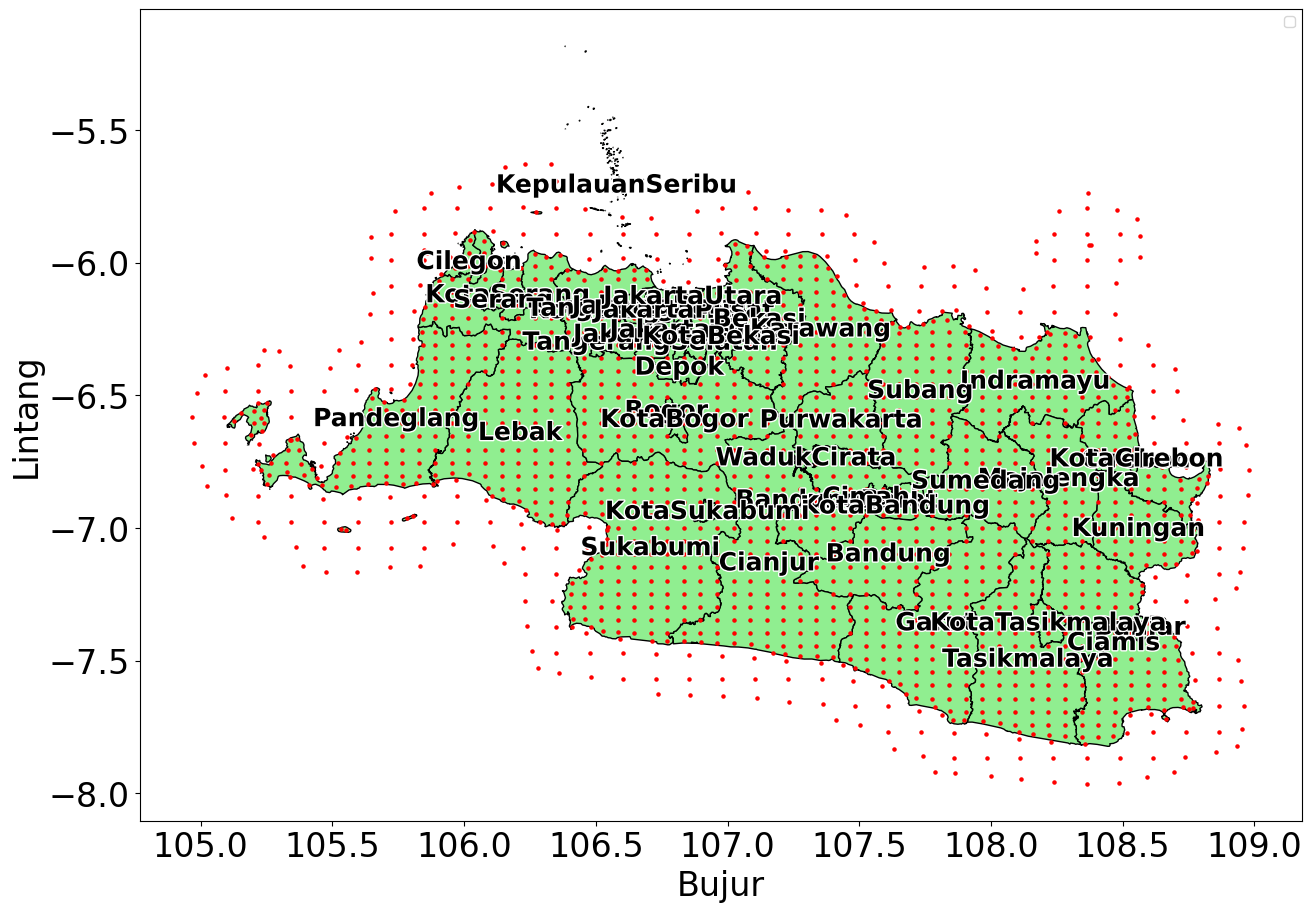

In [26]:
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.patheffects as pe

# Load shapefile of Indonesia level-2
indonesia = gpd.read_file('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_IDN_2.json')

# Create geometry column in df
df['geometry'] = [Point(xy) for xy in zip(df['x_coord'], df['y_coord'])]
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326')


jawa_prov = ['JakartaRaya', 'JawaBarat','Banten']
jawa = indonesia[indonesia['NAME_1'].isin(jawa_prov)]
jawa['centroid'] = jawa.geometry.centroid


# Plot peta Jawa
fig, ax = plt.subplots(figsize=(15,15))
jawa.plot(ax=ax, color='lightgreen', edgecolor='black')

cities_unique = gdf.drop_duplicates(subset=['x_coord', 'y_coord'])

for idx, row in jawa.iterrows():
          ax.annotate(
              text=row['NAME_2'],
              xy=(row['centroid'].x, row['centroid'].y),
              ha='center', va='center',
              fontsize=18, color='black', weight='bold',
              path_effects=[pe.withStroke(linewidth=2, foreground="white")]
          )

cities_unique.plot(ax=ax, color='red', markersize=5)

# Tambahkan judul dan legenda
plt.legend()

plt.xlabel('Bujur', fontsize = 24)
plt.ylabel('Lintang', fontsize = 24)
plt.xticks(fontsize = 24)
plt.yticks(fontsize = 24)
plt.show()

/tmp/ipython-input-3747410134.py:10: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  jawa['centroid'] = jawa.geometry.centroid
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/tmp/ipython-input-3747410134.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


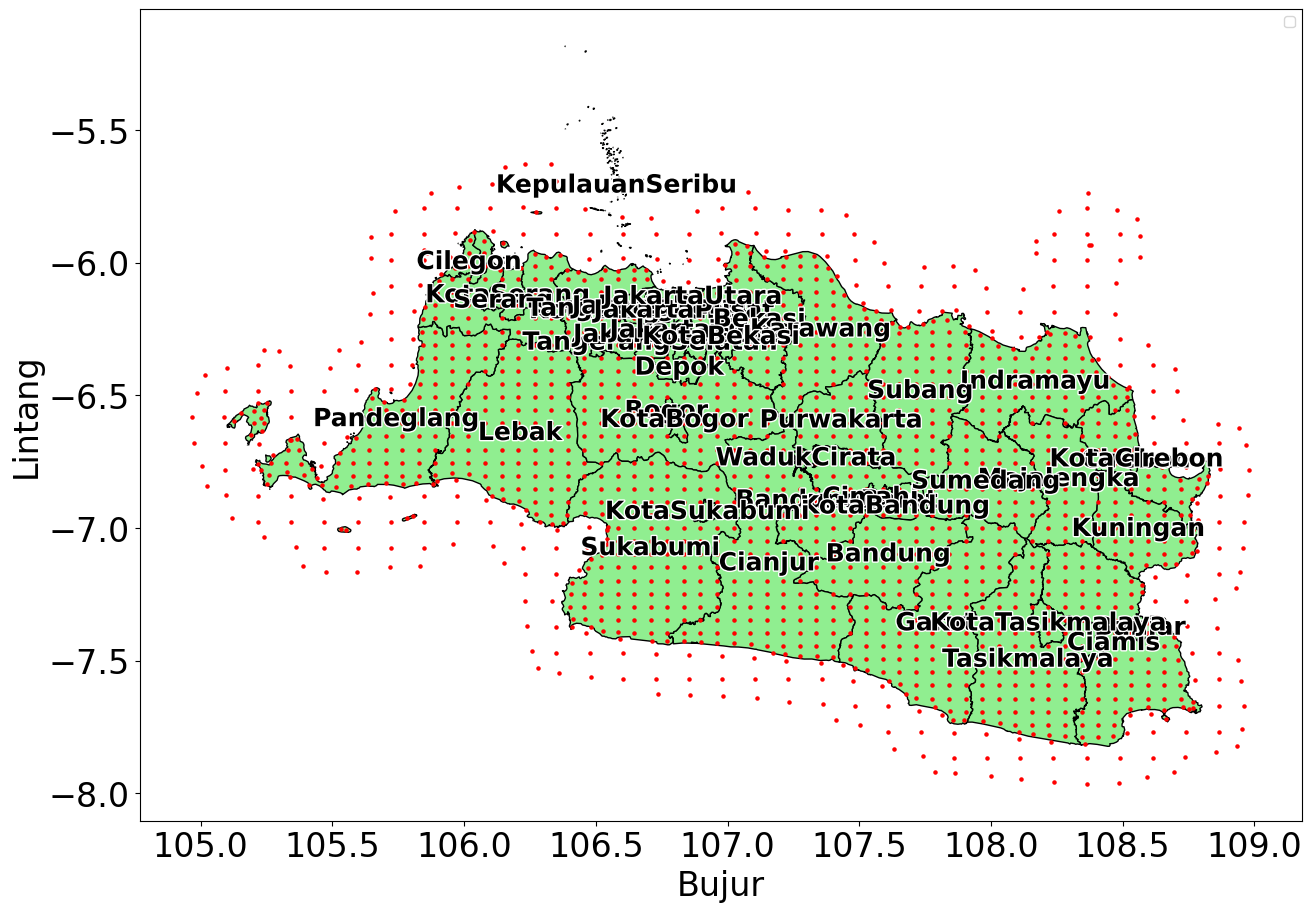

In [27]:
# Load shapefile of Indonesia level-2
# indonesia = gpd.read_file('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_IDN_2.json')

# Create geometry column in df
merged_df['geometry'] = [Point(xy) for xy in zip(merged_df['x_coord'], merged_df['y_coord'])]
gdf = gpd.GeoDataFrame(merged_df, geometry='geometry', crs='EPSG:4326')

jawa_prov = ['JakartaRaya', 'JawaBarat','Banten']
jawa = indonesia[indonesia['NAME_1'].isin(jawa_prov)]
jawa['centroid'] = jawa.geometry.centroid

# Plot peta Jawa
fig, ax = plt.subplots(figsize=(15,15))
jawa.plot(ax=ax, color='lightgreen', edgecolor='black')

cities_unique = gdf.drop_duplicates(subset=['x_coord', 'y_coord'])

for idx, row in jawa.iterrows():
          ax.annotate(
              text=row['NAME_2'],
              xy=(row['centroid'].x, row['centroid'].y),
              ha='center', va='center',
              fontsize=18, color='black', weight='bold',
              path_effects=[pe.withStroke(linewidth=2, foreground="white")]
          )

cities_unique.plot(ax=ax, color='red', markersize=5)

# Tambahkan judul dan legenda
plt.legend()

plt.xlabel('Bujur', fontsize = 24)
plt.ylabel('Lintang', fontsize = 24)
plt.xticks(fontsize = 24)
plt.yticks(fontsize = 24)
plt.show()

In [28]:
merged_df = merged_df[["date","CO_mean","u10","v10","x_coord","y_coord"]]

## Teknik Rescaling

In [29]:
#Convert to Numerical Value
merged_df['time'] = (merged_df['date'] - merged_df['date'].min()).dt.days
scale = 1e-2
merged_df.CO_mean = merged_df.CO_mean/scale
merged_df.x_coord = merged_df.x_coord*100
merged_df.y_coord = merged_df.y_coord*100

In [30]:
merged_df

,date,CO_mean,u10,v10,x_coord,y_coord,time
0,2023-05-01,3.053822,-2.448051,3.632529,10508.845188,-658.182723,0
1,2023-05-01,3.013793,-2.298106,3.647034,10509.243733,-648.404571,0
2,2023-05-01,3.084128,-3.095009,3.721755,10509.243733,-668.164578,0
3,2023-05-01,3.157986,-2.993484,3.448315,10509.243733,-678.044581,0
4,2023-05-01,3.261192,-2.940699,3.310031,10509.621329,-687.732963,0
...,...,...,...,...,...,...,...
806634,2025-04-29,2.190426,-0.058566,1.001686,10895.766144,-707.449003,729
806635,2025-04-29,2.152061,0.027556,0.978412,10895.979937,-697.799717,729
806636,2025-04-29,2.101015,-1.572947,1.042376,10896.006322,-767.053058,729
806637,2025-04-29,2.377350,0.167686,0.929662,10897.444849,-687.655138,729


In [31]:
merged_df.describe()

,date,CO_mean,u10,v10,x_coord,y_coord,time
count,806639,806639.000000,806639.000000,806639.000000,806639.000000,806639.000000,806639.000000
mean,2024-04-03 14:51:41.893164800,3.142782,-0.698624,0.710018,10727.248239,-684.117914,338.619235
min,2023-05-01 00:00:00,0.213090,-4.344528,-0.692771,10496.846881,-796.479403,0.000000
25%,2023-09-28 00:00:00,2.695134,-1.081814,0.057123,10654.508647,-720.835280,150.000000
50%,2024-04-11 00:00:00,3.033256,-0.430998,0.416888,10733.760043,-680.781018,346.000000
75%,2024-09-14 00:00:00,3.474217,-0.045676,1.172490,10802.950043,-645.756892,502.000000
max,2025-04-29 00:00:00,7.155374,0.607264,3.864093,10898.032055,-562.785281,729.000000
std,NaN,0.635194,0.879953,0.888819,92.525054,48.655675,207.259481


## Lowpass FIltering dan Cek Normalitas Residu

In [ ]:
def low_pass_filter(series, cutoff=0.1):
    """Applies a low-pass filter to a pandas Series."""
    signal = series.values
    fft_vals = np.fft.fft(signal)
    freqs = np.fft.fftfreq(len(signal), d=1) # d=1 assumes unit time spacing

    # Apply the ideal low-pass filter
    mask = np.abs(freqs) < cutoff
    filtered_fft = fft_vals * mask

    # Return the real part of the inverse FFT
    return np.fft.ifft(filtered_fft).real

full_dates = pd.date_range(start=merged_df['date'].min(),end=merged_df['date'].max(),freq='D')
coords = merged_df[['x_coord', 'y_coord']].drop_duplicates()
full_index = pd.MultiIndex.from_frame(
    coords.merge(pd.DataFrame({'date': full_dates}), how='cross')
)

merged_df2 = (
    merged_df.set_index(['x_coord', 'y_coord', 'date'])
    .reindex(full_index)
    .reset_index()
    .rename(columns={'level_0': 'x_coord', 'level_1': 'y_coord', 'level_2': 'date'})
)

merged_df2['CO_mean'] = (merged_df2.groupby(['x_coord', 'y_coord'])['CO_mean'].transform(lambda s: s.interpolate(method='linear', limit_direction='both')))
merged_df['CO_filtered'] = merged_df.groupby(['x_coord', 'y_coord'])['CO_mean'].transform(low_pass_filter)
merged_df = merged_df[['date', 'CO_mean','u10','v10','x_coord', 'y_coord','time']].merge(
    merged_df[['date', 'x_coord', 'y_coord', 'CO_filtered']],
    on=['date', 'x_coord', 'y_coord'],
    how='left'
)


# 'df' now contains the new 'CO_filtered' column with the results.
print(merged_df.head())

        date   CO_mean       u10       v10       x_coord     y_coord  time  \
0 2023-05-01  3.053822 -2.448051  3.632529  10508.845188 -658.182723     0   
1 2023-05-01  3.013793 -2.298106  3.647034  10509.243733 -648.404571     0   
2 2023-05-01  3.084128 -3.095009  3.721755  10509.243733 -668.164578     0   
3 2023-05-01  3.157986 -2.993484  3.448315  10509.243733 -678.044581     0   
4 2023-05-01  3.261192 -2.940699  3.310031  10509.621329 -687.732963     0   

   CO_filtered  
0     3.023574  
1     2.952282  
2     3.140671  
3     2.850440  
4     2.840787  


In [33]:
merged_df.describe()

,date,CO_mean,u10,v10,x_coord,y_coord,time,CO_filtered
count,806639,806639.000000,806639.000000,806639.000000,806639.000000,806639.000000,806639.000000,806639.000000
mean,2024-04-03 14:51:41.893164800,3.142782,-0.698624,0.710018,10727.248239,-684.117914,338.619235,3.142782
min,2023-05-01 00:00:00,0.213090,-4.344528,-0.692771,10496.846881,-796.479403,0.000000,1.797669
25%,2023-09-28 00:00:00,2.695134,-1.081814,0.057123,10654.508647,-720.835280,150.000000,2.737778
50%,2024-04-11 00:00:00,3.033256,-0.430998,0.416888,10733.760043,-680.781018,346.000000,3.026278
75%,2024-09-14 00:00:00,3.474217,-0.045676,1.172490,10802.950043,-645.756892,502.000000,3.426945
max,2025-04-29 00:00:00,7.155374,0.607264,3.864093,10898.032055,-562.785281,729.000000,6.517823
std,NaN,0.635194,0.879953,0.888819,92.525054,48.655675,207.259481,0.571362


In [34]:
from scipy.stats import kstest
import pandas as pd


def check_normality(group):
    """
    Calculates KS test for normality on the residuals of a given group.
    """
    residuals = group['CO_mean'] - group['CO_filtered']
    std_residuals = residuals.std()

    # Handle cases where all residuals are the same
    if std_residuals == 0:
        return pd.Series({
            'Test Statistic (KS)': None,
            'P-value (KS)': None,
            'Normality (KS)': "Standard deviation is zero",
            'Data Points': len(residuals)
        })

    # Perform the KS test
    mean_residuals = residuals.mean()
    stat, p = kstest(residuals, 'norm', args=(mean_residuals, std_residuals))

    # Determine normality based on the p-value
    normality = "Gaussian" if p > 0.01 else "Not Gaussian"

    return pd.Series({
        'Test Statistic (KS)': stat,
        'P-value (KS)': p,
        'Normality (KS)': normality,
        'Data Points': len(residuals)
    })

# Group by coordinates only and apply the function
normality_results_df = merged_df.groupby(['x_coord', 'y_coord']).apply(check_normality).reset_index()

# Display the first few rows of the results
print(normality_results_df.head())

        x_coord     y_coord  Test Statistic (KS)  P-value (KS) Normality (KS)  \
0  10496.846881 -658.367252             0.031508      0.881867       Gaussian   
1  10497.469700 -667.856897             0.033466      0.825746       Gaussian   
2  10498.576128 -649.072249             0.031253      0.923156       Gaussian   
3  10500.371938 -676.720681             0.044365      0.682444       Gaussian   
4  10501.484859 -642.320911             0.064645      0.370037       Gaussian   

   Data Points  
0          336  
1          342  
2          299  
3          254  
4          196  


/tmp/ipython-input-2513095222.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  normality_results_df = merged_df.groupby(['x_coord', 'y_coord']).apply(check_normality).reset_index()


In [35]:
normality_results_df["Normality (KS)"].value_counts()

,count
Normality (KS),
Gaussian,1693


In [36]:
merged_df.describe()

,date,CO_mean,u10,v10,x_coord,y_coord,time,CO_filtered
count,806639,806639.000000,806639.000000,806639.000000,806639.000000,806639.000000,806639.000000,806639.000000
mean,2024-04-03 14:51:41.893164800,3.142782,-0.698624,0.710018,10727.248239,-684.117914,338.619235,3.142782
min,2023-05-01 00:00:00,0.213090,-4.344528,-0.692771,10496.846881,-796.479403,0.000000,1.797669
25%,2023-09-28 00:00:00,2.695134,-1.081814,0.057123,10654.508647,-720.835280,150.000000,2.737778
50%,2024-04-11 00:00:00,3.033256,-0.430998,0.416888,10733.760043,-680.781018,346.000000,3.026278
75%,2024-09-14 00:00:00,3.474217,-0.045676,1.172490,10802.950043,-645.756892,502.000000,3.426945
max,2025-04-29 00:00:00,7.155374,0.607264,3.864093,10898.032055,-562.785281,729.000000,6.517823
std,NaN,0.635194,0.879953,0.888819,92.525054,48.655675,207.259481,0.571362


In [37]:
averaged_df = merged_df.groupby(['x_coord', 'y_coord'])[['u10', 'v10']].mean().reset_index()
df_for_update = merged_df.drop(columns=['u10', 'v10'])
filtered_df = pd.merge(df_for_update, averaged_df, on=['x_coord', 'y_coord'], how='left')
filtered_df

,date,CO_mean,x_coord,y_coord,time,CO_filtered,u10,v10
0,2023-05-01,3.053822,10508.845188,-658.182723,0,3.023574,-2.448051,3.632529
1,2023-05-01,3.013793,10509.243733,-648.404571,0,2.952282,-2.298106,3.647034
2,2023-05-01,3.084128,10509.243733,-668.164578,0,3.140671,-3.095009,3.721755
3,2023-05-01,3.157986,10509.243733,-678.044581,0,2.850440,-2.993484,3.448315
4,2023-05-01,3.261192,10509.621329,-687.732963,0,2.840787,-2.940699,3.310031
...,...,...,...,...,...,...,...,...
806634,2025-04-29,2.190426,10895.766144,-707.449003,729,2.734591,-0.058566,1.001686
806635,2025-04-29,2.152061,10895.979937,-697.799717,729,2.874558,0.027556,0.978412
806636,2025-04-29,2.101015,10896.006322,-767.053058,729,2.625233,-1.572947,1.042376
806637,2025-04-29,2.377350,10897.444849,-687.655138,729,2.943248,0.167686,0.929662


In [38]:
filtered_df

,date,CO_mean,x_coord,y_coord,time,CO_filtered,u10,v10
0,2023-05-01,3.053822,10508.845188,-658.182723,0,3.023574,-2.448051,3.632529
1,2023-05-01,3.013793,10509.243733,-648.404571,0,2.952282,-2.298106,3.647034
2,2023-05-01,3.084128,10509.243733,-668.164578,0,3.140671,-3.095009,3.721755
3,2023-05-01,3.157986,10509.243733,-678.044581,0,2.850440,-2.993484,3.448315
4,2023-05-01,3.261192,10509.621329,-687.732963,0,2.840787,-2.940699,3.310031
...,...,...,...,...,...,...,...,...
806634,2025-04-29,2.190426,10895.766144,-707.449003,729,2.734591,-0.058566,1.001686
806635,2025-04-29,2.152061,10895.979937,-697.799717,729,2.874558,0.027556,0.978412
806636,2025-04-29,2.101015,10896.006322,-767.053058,729,2.625233,-1.572947,1.042376
806637,2025-04-29,2.377350,10897.444849,-687.655138,729,2.943248,0.167686,0.929662


In [39]:
filtered_df.describe()

,date,CO_mean,x_coord,y_coord,time,CO_filtered,u10,v10
count,806639,806639.000000,806639.000000,806639.000000,806639.000000,806639.000000,806639.000000,806639.000000
mean,2024-04-03 14:51:41.893164800,3.142782,10727.248239,-684.117914,338.619235,3.142782,-0.698624,0.710018
min,2023-05-01 00:00:00,0.213090,10496.846881,-796.479403,0.000000,1.797669,-4.344528,-0.692771
25%,2023-09-28 00:00:00,2.695134,10654.508647,-720.835280,150.000000,2.737778,-1.081814,0.057123
50%,2024-04-11 00:00:00,3.033256,10733.760043,-680.781018,346.000000,3.026278,-0.430998,0.416888
75%,2024-09-14 00:00:00,3.474217,10802.950043,-645.756892,502.000000,3.426945,-0.045676,1.172490
max,2025-04-29 00:00:00,7.155374,10898.032055,-562.785281,729.000000,6.517823,0.607264,3.864093
std,NaN,0.635194,92.525054,48.655675,207.259481,0.571362,0.879953,0.888819


In [40]:
# Select up to 20 unique locations randomly follows "Gaussian"
gaussian_locations = normality_results_df[normality_results_df['Normality (KS)'] == 'Gaussian'][['x_coord', 'y_coord']]

selected_locations = gaussian_locations.sample(min(20, len(gaussian_locations)), random_state=42)

# Plot for each selected location
for index, row in selected_locations.iterrows():
    x_c, y_c = row['x_coord'], row['y_coord']

    # Filter data for the current location
    location_data = merged_df[(merged_df['x_coord'] == x_c) & (merged_df['y_coord'] == y_c)].copy()
    if location_data.empty:
        print(f"No data found for location ({x_c}, {y_c}). Skipping.")
        continue

    # Calculate residuals
    location_data['residuals'] = location_data['CO_mean'] - location_data['CO_filtered']

    # Sort by time for plotting
    location_data.sort_values(by='time', inplace=True)

    # --- Combined Plot ---
    plt.figure(figsize=(12, 4))
    plt.title(f'Konsentrasi CO, Filtering, dan Residu di titik ({x_c/100:.2f}, {y_c/100:.2f})', fontsize=14)

    # Original data (blue)
    plt.plot(location_data['time'], location_data['CO_mean'], label='Data Asli', color='blue')

    # Filtered data (orange)
    plt.plot(location_data['time'], location_data['CO_filtered'], label='Data Hasil Filtering', color='orange')

    # Residuals (gray, transparent)
    plt.plot(location_data['time'], location_data['residuals'], label='Residu', color='gray', alpha=0.6)

    plt.xlabel("Waktu (t)")
    plt.ylabel("Konsentrasi CO dalam 10^-2 mol/m^2")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --- Residuals Histogram ---
    plt.figure(figsize=(10, 6))
    plt.hist(location_data['residuals'], bins=40, color='gray', alpha=0.7, label='Residuals')
    plt.title(f'Distribusi Residu Filtering di titik ({x_c/100:.2f}, {y_c/100:.2f})')
    plt.xlabel("Residu")
    plt.ylabel("Frekuensi")
    plt.legend()
    plt.grid(True)
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [41]:

# Filter locations with 'Not Gaussian' residuals
not_gaussian_locations = normality_results_df[normality_results_df['Normality (KS)'] == 'Not Gaussian'][['x_coord', 'y_coord']]
# Select up to 20 unique locations randomly
selected_locations = not_gaussian_locations.sample(min(20, len(not_gaussian_locations)), random_state=42)

# Plot for each selected location
for index, row in selected_locations.iterrows():
    x_c, y_c = row['x_coord'], row['y_coord']

    # Filter data for the current location
    location_data = merged_df[(merged_df['x_coord'] == x_c) & (merged_df['y_coord'] == y_c)].copy()
    if location_data.empty:
        print(f"No data found for location ({x_c}, {y_c}). Skipping.")
        continue

    # Calculate residuals
    location_data['residuals'] = location_data['CO_mean'] - location_data['CO_filtered']

    # Sort by time for plotting
    location_data.sort_values(by='time', inplace=True)

    # --- Combined Plot ---
    plt.figure(figsize=(12, 4))
    plt.title(f'Konsentrasi CO, Filtering, dan Residu di titik ({x_c/100:.2f}, {y_c/100:.2f})', fontsize=14)

    # Original data (blue)
    plt.plot(location_data['time'], location_data['CO_mean'], label='Data Asli', color='blue')

    # Filtered data (orange)
    plt.plot(location_data['time'], location_data['CO_filtered'], label='Data Hasil Filtering', color='orange')

    # Residuals (gray, transparent)
    plt.plot(location_data['time'], location_data['residuals'], label='Residu', color='gray', alpha=0.6)

    plt.xlabel("Waktu (t)")
    plt.ylabel("Konsentrasi CO dalam 10^-2 mol/m^2")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --- Residuals Histogram ---
    plt.figure(figsize=(10, 6))
    plt.hist(location_data['residuals'], bins=40, color='gray', alpha=0.7, label='Residuals')
    plt.title(f'Distribusi Residu Filtering di titik ({x_c/100:.2f}, {y_c/100:.2f})')
    plt.xlabel("Residu")
    plt.ylabel("Frekuensi")
    plt.legend()
    plt.grid(True)
    plt.show()

# Split Train Testing

In [42]:
np.random.seed(42)


shuffled_df = filtered_df.sample(frac=1).reset_index(drop=True)

split_ratio = 0.7

# Calculate the number of training samples
train_size = int(split_ratio * len(shuffled_df))

# Split the data
train_df = shuffled_df[:train_size]
test_df = shuffled_df[train_size:]

# Convert to tensors
X_train = tf.convert_to_tensor(train_df[['time','x_coord', 'y_coord']].values, dtype= tf.float32)
u_train =  tf.convert_to_tensor(train_df['CO_filtered'].values.reshape(-1, 1), dtype= tf.float32)

X_test =  tf.convert_to_tensor(test_df[['time','x_coord', 'y_coord']].values, dtype= tf.float32)
u_test =  tf.convert_to_tensor(test_df['CO_filtered'].values.reshape(-1, 1), dtype= tf.float32)

W_u =tf.convert_to_tensor(train_df[[ 'u10']].values, dtype= tf.float32)
W_v =tf.convert_to_tensor(train_df[['v10']].values, dtype= tf.float32)

In [43]:
X_train

<tf.Tensor: shape=(564647, 3), dtype=float32, numpy=
array([[   55.     , 10696.0205 ,  -630.9369 ],
       [  389.     , 10645.899  ,  -734.43884],
       [   52.     , 10821.82   ,  -744.5569 ],
       ...,
       [  150.     , 10589.09   ,  -625.9969 ],
       [   92.     , 10601.884  ,  -679.83746],
       [  349.     , 10784.08   ,  -754.4369 ]], dtype=float32)>

In [44]:
X_test

<tf.Tensor: shape=(241992, 3), dtype=float32, numpy=
array([[  599.     , 10821.222  ,  -626.0001 ],
       [  546.     , 10689.73   ,  -635.8769 ],
       [  195.     , 10897.445  ,  -687.65515],
       ...,
       [  101.     , 10752.63   ,  -655.6369 ],
       [  556.     , 10625.734  ,  -746.3549 ],
       [   94.     , 10765.21   ,  -675.3969 ]], dtype=float32)>

In [45]:
u_train

<tf.Tensor: shape=(564647, 1), dtype=float32, numpy=
array([[3.6220798],
       [3.4767683],
       [2.7299118],
       ...,
       [3.9333267],
       [2.8910427],
       [2.5686753]], dtype=float32)>

In [46]:
u_test

<tf.Tensor: shape=(241992, 1), dtype=float32, numpy=
array([[2.8489237],
       [4.5385637],
       [4.4049435],
       ...,
       [3.3021593],
       [4.0973887],
       [2.4235368]], dtype=float32)>

In [47]:
W_u

<tf.Tensor: shape=(564647, 1), dtype=float32, numpy=
array([[-0.16712716],
       [-2.3242023 ],
       [-0.8142819 ],
       ...,
       [ 0.20150217],
       [-0.9910876 ],
       [-1.1253635 ]], dtype=float32)>

In [48]:
W_v

<tf.Tensor: shape=(564647, 1), dtype=float32, numpy=
array([[-0.19507386],
       [ 1.8792492 ],
       [ 0.3597551 ],
       ...,
       [ 1.444747  ],
       [ 2.2031944 ],
       [ 0.37422186]], dtype=float32)>

# Persiapan PINN

## Persiapan Arsitektur PINN

In [49]:
lb = filtered_df[['time','x_coord', 'y_coord']].min().values
ub = filtered_df[['time','x_coord', 'y_coord']].max().values

In [50]:
ub-lb

array([729.        , 401.18517402, 233.69412157])

In [51]:
arch = {'output_dim':1, 'num_hidden_layers':5, 'num_neurons_per_layer':100,'activation':'tanh', 'trainable_B':True, 'sigmas':[1,2], 'mapping_size':64}
n_models = 20

models = [None] * n_models

for i in range(n_models):
  tf.random.set_seed(i)
  models[i] = Hybrid_IdentificationNet(initial_lambda=0.0, lb=lb, ub=ub, **arch)
  models[i].build((None, 3))

## Persiapan Automatic Differentiation dan Fungsi Loss

### Inverse Method

In [52]:
def get_r_inv(t, x, y, model, lambd, fun_r,u_data=u_train, Wu=W_u, Wv=W_v):
    """
    Computes the residuals of the PDE using automatic differentiation.
    """
    t = tf.cast(t, tf.float32)
    x = tf.cast(x, tf.float32)
    y = tf.cast(y, tf.float32)
    # Ensure Wu and Wv are tensors if not None
    if Wu is not None:
        Wu = tf.convert_to_tensor(Wu, dtype=tf.float32)
    if Wv is not None:
        Wv = tf.convert_to_tensor(Wv, dtype=tf.float32)


    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(y)
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t)
            tape2.watch(x)
            tape2.watch(y)

            # Combine inputs for model prediction (adjust order if needed)
            inputs = tf.concat([t, x, y], axis=1)  # or [x, y, t] if your model expects that
            u_pred = model(inputs)  # model prediction, shape (batch_size, 1)

        u_t = tape2.gradient(u_pred, t)
        u_x = tape2.gradient(u_pred, x)
        u_y = tape2.gradient(u_pred, y)

    u_xx = tape.gradient(u_x, x)
    u_yy = tape.gradient(u_y, y)
    del tape
    del tape2

    return fun_r(t, x, y, u_pred, u_t, u_x,u_y, u_xx, u_yy, model, u_data, Wu=Wu, Wv=Wv) # Pass u_data, Wu, Wv

def fun_r_inv(t, x, y, u_pred, u_t,u_x,u_y, u_xx, u_yy, model, u_data= u_train, Wu=W_u, Wv=W_v): # Added Wu, Wv here
    # tf.print(tf.reduce_mean(u_x))
    # tf.print(tf.reduce_mean(u_y))
    # tf.print(tf.reduce_mean(u_xx))
    # tf.print(tf.reduce_mean(u_yy))
    pde_residual = scale*(u_t) +scale* W_u * u_x + scale*Wv * u_y- model.lambd * (scale*u_xx + scale*u_yy)
    loss = tf.reduce_mean(tf.square(pde_residual))
    return loss

def get_r_param(t, x, y, Wu, Wv, model):
    t = tf.cast(t, tf.float32)
    x = tf.cast(x, tf.float32)
    y = tf.cast(y, tf.float32)
    Wu = tf.cast(Wu, tf.float32)
    Wv = tf.cast(Wv, tf.float32)


    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(y)
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t)
            tape2.watch(x)
            tape2.watch(y)

            # Combine inputs for model prediction (adjust order if needed)
            inputs = tf.concat([t, x, y], axis=1)  # or [x, y, t] if your model expects that
            u_pred = model(inputs)  # model prediction, shape (batch_size, 1)

        u_t = tape2.gradient(u_pred, t)
        u_x = tape2.gradient(u_pred, x)
        u_y = tape2.gradient(u_pred, y)

    u_xx = tape.gradient(u_x, x)
    u_yy = tape.gradient(u_y, y)

    del tape
    del tape2

    with tf.GradientTape(persistent=True) as tape_lambd:
      tape_lambd.watch(model.lambd)
      pde_residual = scale*(u_t) +scale* Wu * u_x + scale*Wv * u_y- model.lambd * (scale*u_xx + scale*u_yy)

      loss = tf.reduce_mean(tf.square(pde_residual))
    g = tape_lambd.gradient(loss, model.lambd)

    del tape_lambd

    return loss, g

### Forward Method

In [53]:
def get_r_fwd(t, x, y, model, lambd, fun_r,u_data=u_train, Wu=W_u, Wv=W_v): # Added Wu and Wv here
    """
    Computes the residuals of the PDE using automatic differentiation.
    """
    t = tf.convert_to_tensor(t, dtype=tf.float32)
    x = tf.convert_to_tensor(x, dtype=tf.float32)
    y = tf.convert_to_tensor(y, dtype=tf.float32)
    # Ensure Wu and Wv are tensors if not None
    if Wu is not None:
        Wu = tf.convert_to_tensor(Wu, dtype=tf.float32)
    if Wv is not None:
        Wv = tf.convert_to_tensor(Wv, dtype=tf.float32)


    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(y)
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t)
            tape2.watch(x)
            tape2.watch(y)
            u = model(tf.concat([t, x,y], axis=1))  # Ensure proper tensor shape
        u_t = tape2.gradient(u, t)
        u_x = tape2.gradient(u, x)
        u_y = tape2.gradient(u, y)

    u_xx = tape.gradient(u_x, x)
    u_yy = tape.gradient(u_y, y)
    del tape
    del tape2
    return fun_r_fwd(t, x, y, u, u_t,u_x,u_y,u_xx, u_yy, model,lambd,u_data, Wu=Wu, Wv=Wv) # Pass Wu and Wv here

def fun_r_fwd(t, x, y, u, u_t,u_x,u_y, u_xx, u_yy, model,lambd, u_data= u_train, weight_pde=1, weight_data=10,  Wu=W_u, Wv=W_v): # Added Wu and Wv here
    if Wu is None or Wv is None:
        print("Warning: Wu or Wv is None in fun_r_fwd")

    pde_residual = scale*(u_t) +scale* Wu * u_x + scale*Wv * u_y- lambd * (scale*u_xx + scale*u_yy)
    pde_loss = tf.reduce_mean(tf.square(pde_residual))

    u_pred_data = u
    data_loss = tf.reduce_mean(tf.square((u_pred_data - u_data)))

    total_loss = weight_pde * pde_loss + weight_data*data_loss
    tf.print("PDE Loss:", pde_loss, "Data Loss:",data_loss, "Total Loss:", total_loss)
    return total_loss

# Pelatihan Invers

In [ ]:
lr_comb_param = {'boundaries': [7000,10000,11000,13000,15000,20000],
                 'initial_learning_rate': 1e-2,
                 'decay_steps': 1000,
                 'decay_rate': 0.9,
                 'values_steps': 2}
lr_comb = CombinedDecays(**lr_comb_param)
lr_comb.get_config()

{'initial_learning_rate': 0.01,
 'decay_steps': 1000,
 'decay_rate': 0.9,
 'staircase': False,
 'boundaries': [7000, 10000, 11000, 13000, 15000, 20000],
 'values': [0.004782969000000001,
  0.0023914845000000003,
  0.0011957422500000002,
  0.0005978711250000001,
  0.00029893556250000004,
  0.00014946778125000002,
  7.473389062500001e-05],
 'values_steps': [2, 2, 2, 2, 2, 2],
 'name': None}

In [ ]:
timeout = 120
initial_lambdas = [0.5]

old_timeout = timeout
models_Adam = [None] * n_models
hists_Adam = [None] * n_models

for i in range(n_models):
  timeout = old_timeout
  models_Adam[i] = []
  hists_Adam[i] = []

  for j in range(len(initial_lambdas)):
    print('{:s}\nIteration: {:d} Initial lambda: {}\n{:s}'.format(50*'-',i+1,initial_lambdas[j],50*'-'))
    # Prepare models' architecture
    tf.random.set_seed(i + j)
    models_Adam[i].append(Hybrid_IdentificationNet(initial_lambda=initial_lambdas[j], lb=lb, ub=ub, **arch))

    models_Adam[i][j].build((None, 3))

    # Copy weights from the previous model instance to make every iteration comparable
    models_Adam[i][j].set_weights(models[i].get_weights())

    # Assigning initial lambda
    # models_Adam[i][j].trainable_variables[-1].assign(initial_lambdas[j])
    models_Adam[i][j].initial_lambda = initial_lambdas[j]

    # Prepare optimizer
    optim_Adam = tf.keras.optimizers.AdamW(learning_rate=lr_comb, weight_decay = 0.0001)
    optim_inv_Adam = tf.keras.optimizers.AdamW(learning_rate=lr_comb, weight_decay = 0.0001)

    # Initialize solver
    solver_Adam = Hybrid_IdentificationSolver(models_Adam[i][j], X_train,fun_r_inv, get_r_inv)

    # Train models
    print('\n\nAdam\n')
    solver_Adam.solve_with_TFoptimizer(optim_Adam, optim_inv_Adam, get_r_param, X_train, u_train, W_u, W_v, timeout_param=timeout*0.2, timeout_fwd=timeout*0.8)

    # Store evolution of lambdas and hists
    hists_Adam[i].append([models_Adam[i][j].lambd_list, solver_Adam.hist])

    print('\n\n\n')

--------------------------------------------------
Iteration: 1 Initial lambda: 0.5
--------------------------------------------------


Adam



Forward optimization (full dataset)


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:855: UserWarning: Gradients do not exist for variables ['Variable:0'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


Streaming output truncated to the last 5000 lines.
Iteration 1238, Loss: 0.041269633919000626
Iteration 1239, Loss: 0.039343416690826416
Iteration 1240, Loss: 0.0385945625603199
Iteration 1241, Loss: 0.03909427300095558
Iteration 1242, Loss: 0.040303319692611694
Iteration 1243, Loss: 0.041853055357933044
Iteration 1244, Loss: 0.04292307421565056
Iteration 1245, Loss: 0.043825432658195496
Iteration 1246, Loss: 0.043119464069604874
Iteration 1247, Loss: 0.04191345348954201
Iteration 1248, Loss: 0.03993282467126846
Iteration 1249, Loss: 0.03869045153260231
Iteration 1250, Loss: 0.03862154111266136
Iteration 1251, Loss: 0.03951135277748108
Iteration 1252, Loss: 0.04087367653846741
Iteration 1253, Loss: 0.04203737899661064
Iteration 1254, Loss: 0.0431864894926548
Iteration 1255, Loss: 0.043124567717313766
Iteration 1256, Loss: 0.04267768934369087
Iteration 1257, Loss: 0.04094212129712105
Iteration 1258, Loss: 0.039354145526885986
Iteration 1259, Loss: 0.03845822438597679
Iteration 1260, Los

In [ ]:
path = dir + "CO_Model/GridedJabar_Fourier_tanh_inv/"


In [ ]:
for i in range(n_models):
  for j in range(len(initial_lambdas)):
    models_Adam[i][j].save_weights(path+"_"+str(i)+"_model_Adam_"+str(j)+".weights.h5", 'h5')
for i in range(n_models):
  for j in range(len(initial_lambdas)):
    np.savetxt(path + "loss/hist_Adam_" + str(i) + "_" + str(j) + ".csv", hists_Adam[i][j][1], delimiter=",")

for i in range(n_models):
  for j in range(len(initial_lambdas)):
    np.savetxt(path + "loss/lambd_Adam_" + str(i) + "_" + str(j) + ".csv", hists_Adam[i][j][0], delimiter=",")

In [ ]:
n_models=60
hists_Adam1 = [None] * n_models
lambd_Adam1 = [None] * n_models

for i in range(0,n_models):
    hists_Adam1[i] = []
    lambd_Adam1[i]=[]
    for j in range(len(initial_lambdas)):
        hists_Adam1[i].append(pd.read_csv(path + "/loss/hist_Adam_" + str(i) + "_" + str(j) + ".csv",header=None).transpose())
        lambd_Adam1[i].append(pd.read_csv(path + "/loss/lambd_Adam_" + str(i) + "_" + str(j) + ".csv",header=None).transpose())

## Grafik Loss

<>:9: SyntaxWarning: invalid escape sequence '\h'
<>:9: SyntaxWarning: invalid escape sequence '\h'
<>:9: SyntaxWarning: invalid escape sequence '\h'
<>:9: SyntaxWarning: invalid escape sequence '\h'
<>:9: SyntaxWarning: invalid escape sequence '\h'
<>:9: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipython-input-3555601903.py:9: SyntaxWarning: invalid escape sequence '\h'
  cols = ['$\hat{\lambda}_{1_0}^{(1)} = -1$', '$\hat{\lambda}_{1_0}^{(1)} = -2$', '$\hat{\lambda}_{1_0}^{(1)} = -5$']
/tmp/ipython-input-3555601903.py:9: SyntaxWarning: invalid escape sequence '\h'
  cols = ['$\hat{\lambda}_{1_0}^{(1)} = -1$', '$\hat{\lambda}_{1_0}^{(1)} = -2$', '$\hat{\lambda}_{1_0}^{(1)} = -5$']
/tmp/ipython-input-3555601903.py:9: SyntaxWarning: invalid escape sequence '\h'
  cols = ['$\hat{\lambda}_{1_0}^{(1)} = -1$', '$\hat{\lambda}_{1_0}^{(1)} = -2$', '$\hat{\lambda}_{1_0}^{(1)} = -5$']


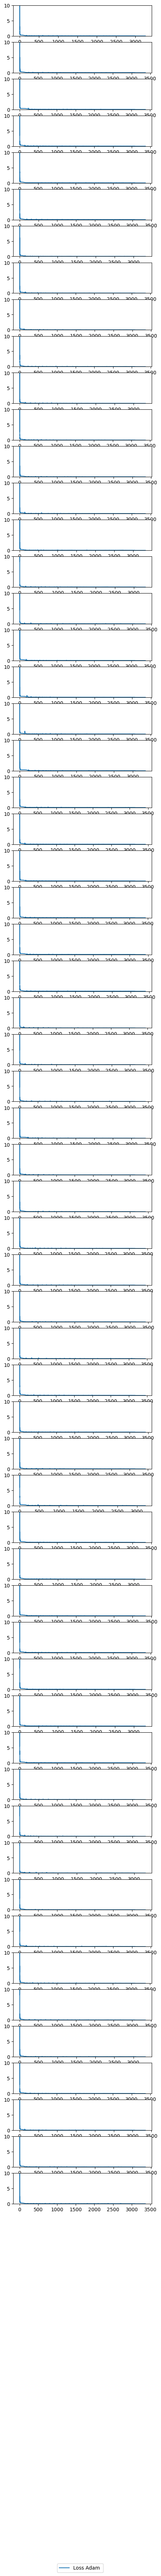

In [ ]:
fig, axes = plt.subplots(nrows=n_models, ncols=len(initial_lambdas), figsize=(5,80))

# fig, axes = plt.subplots(nrows=n_models, ncols=len(initial_lambdas), figsize=(15,5))

for i in range(n_models):
  axes[i].plot(np.linspace(0, len(hists_Adam1[i][0].transpose()),len(hists_Adam1[i][0].transpose())), hists_Adam1[i][0].transpose())
  axes[i].set_ylim([0,1e1])

cols = ['$\hat{\lambda}_{1_0}^{(1)} = -1$', '$\hat{\lambda}_{1_0}^{(1)} = -2$', '$\hat{\lambda}_{1_0}^{(1)} = -5$']
rows = ['Attempt {}'.format(row) for row in range(1, n_models+1)]


fig.legend(['Loss Adam '], loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=True)

plt.show()

## Predict and Evaluate Inverse Problem

In [ ]:
def lambdas(hists, iter_model, iter_init):
  return lambd_Adam1[i][0].transpose().iloc[-1,:].values[0]

df = pd.DataFrame(columns=['Adam'])
df = df.round(10)

for i in range(n_models):
  x = []
  for j in range(len(initial_lambdas)):
    x.append(lambdas(hists_Adam1, i, j))

  df.loc['Attempt '+str(i+1)] = x

print("Lambda Prediction Given U(x,t)")
df

Lambda Prediction Given U(x,t)


,Adam
Attempt 1,0.497573
Attempt 2,0.496511
Attempt 3,0.497207
Attempt 4,0.497920
Attempt 5,0.498111
Attempt 6,0.496835
Attempt 7,0.496241
Attempt 8,0.497554
Attempt 9,0.496655
Attempt 10,0.497984


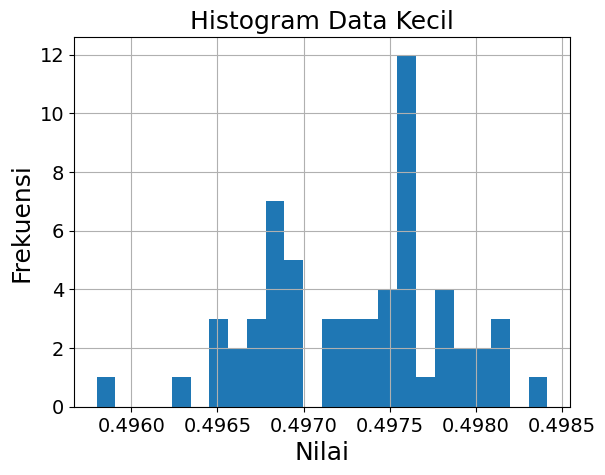

In [ ]:
bins = np.linspace(min(df.Adam), max(df.Adam), 25)  # 20 bins antara 0 dan 0.0001
ax = df.iloc[:, 0].plot(kind='hist', bins=bins, align='mid')

# plt.xticks(np.linspace(0, 0.00008, 11))  # Misal xtick tiap 0.00001
plt.xlabel("Nilai",fontsize=18)
plt.ylabel("Frekuensi",fontsize=18)
plt.title("Histogram Data Kecil",fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=14)  # misal 14
plt.grid(True)
plt.show()

beta         KS=0.0889, p=0.6965, params=(np.float64(7.5785573012035545), np.float64(4.161963242560337), np.float64(0.494744267617992), np.float64(0.003963409887436576))
norm         KS=0.0986, p=0.5704, params=(np.float64(0.4973025212685267), np.float64(0.0005308085524159378))
lognorm      KS=0.0986, p=0.5704, params=(np.float64(5.709991989002324e-06), -92.46412510778093, np.float64(92.96142762753398))
gamma        KS=0.1026, p=0.5192, params=(np.float64(335.40411676066344), np.float64(0.4874925288160039), np.float64(2.9245996395185207e-05))
invgauss     KS=0.1196, p=0.3304, params=(np.float64(0.01666288564034403), np.float64(0.4929485442128654), np.float64(0.2603190069263689))
uniform      KS=0.2441, p=0.001238, params=(0.49579799175262446, 0.0026182830333709717)
fisk         KS=0.2567, p=0.0005641, params=(np.float64(7291218091.074701), np.float64(-6476091.180226572), np.float64(6476091.677533032))
expon        KS=0.3511, p=4.069e-07, params=(0.49579799175262446, 0.00150452951590224

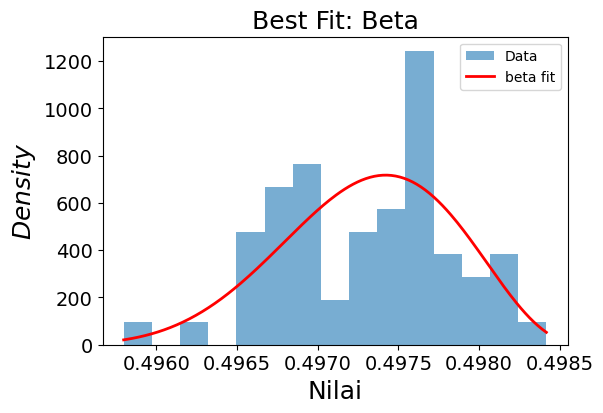

Mean Beta: 0.4973026660150758


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# If df is a DataFrame, pick the column you want to fit:
data = df.iloc[:, 0].to_numpy()  # 1D array

distributions = [
    stats.norm,          # Normal
    stats.expon,         # Exponential
    stats.gamma,         # Gamma
    stats.beta,          # Beta
    stats.lognorm,       # Lognormal
    stats.uniform,       # Uniform
    stats.invgauss,      # Inverse Gaussian
    stats.burr,          # Burr
    stats.fisk,          # Fisk (log-logistic)
    stats.gengamma       # Generalized Gamma
]

results = {}

# Fit tiap distribusi dan uji KS
for dist in distributions:
    try:
        params = dist.fit(data)
        ks_stat, ks_pval = stats.kstest(data, dist.cdf, args=params)
        results[dist.name] = {
            "KS_stat": float(ks_stat),
            "p_value": float(ks_pval),
            "params": params
        }
    except Exception as e:
        results[dist.name] = {"KS_stat": np.inf, "p_value": 0, "params": None}
        print(f"Gagal fit {dist.name}: {e}")

# Urutkan dari KS terkecil
sorted_results = sorted(results.items(), key=lambda x: x[1]["KS_stat"])

# Tampilkan hasil
for name, res in sorted_results:
    if res["params"] is not None:
        print(f"{name:12s} KS={res['KS_stat']:.4f}, p={res['p_value']:.4g}, params={res['params']}")

# Plot best fit
best_name, best_info = sorted_results[0]
best_dist = getattr(stats, best_name)
params = best_info["params"]

x = np.linspace(min(data), max(data), 200)
pdf = best_dist.pdf(x, *params)

plt.figure(figsize=(6,4))
plt.hist(data, bins=15, density=True, alpha=0.6, label="Data")
plt.plot(x, pdf, 'r-', lw=2, label=f"{best_name} fit")
plt.title(f"Best Fit: {best_name.capitalize()}",fontsize=18)
plt.xlabel("Nilai",fontsize=18)
plt.ylabel(r"$Density$",fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=14)  # misal 14

plt.legend()
plt.show()

params = stats.beta.fit(data)
mean = stats.beta.mean(*params)
print("Mean Beta:", mean)

In [ ]:
print(df.mean(axis=0).round(10))
df.loc['Average'] = df.mean(axis=0)
df.loc['StdDev'] = df.std(axis=0, ddof=1)
df.loc['CV'] = df.loc['StdDev'] / df.loc['Average']
df.loc[['Average', 'StdDev', 'CV']] = df.loc[['Average', 'StdDev', 'CV']].round(10)
print(df.tail(3))

Adam    0.497303
dtype: float64
             Adam
Average  0.497303
StdDev   0.000531
CV       0.001067


# Pelatihan Kasus Forward

In [54]:
n_models = 2

arch = {'output_dim':1, 'num_hidden_layers':5, 'num_neurons_per_layer':100,'activation':'tanh', 'trainable_B':True, 'sigmas':[1.0,2.0], 'mapping_size':64}

models = [None] * n_models

for i in range(n_models):
  tf.random.set_seed(i)
  models[i] = PINN_NeuralNet(lb=lb, ub=ub, **arch)
  models[i].build((None, 3))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


In [55]:
lr_comb_param = {'boundaries': [7000,10000,11000,13000,15000,20000],
                 'initial_learning_rate': 1e-2,
                 'decay_steps': 1000,
                 'decay_rate': 0.9,
                 'values_steps': 2}
lr_comb = CombinedDecays(**lr_comb_param)
lr_comb.get_config()

{'initial_learning_rate': 0.01,
 'decay_steps': 1000,
 'decay_rate': 0.9,
 'staircase': False,
 'boundaries': [7000, 10000, 11000, 13000, 15000, 20000],
 'values': [0.004782969000000001,
  0.0023914845000000003,
  0.0011957422500000002,
  0.0005978711250000001,
  0.00029893556250000004,
  0.00014946778125000002,
  7.473389062500001e-05],
 'values_steps': [2, 2, 2, 2, 2, 2],
 'name': None}

Text(0.5, 1, 'Combined Learning Rate')

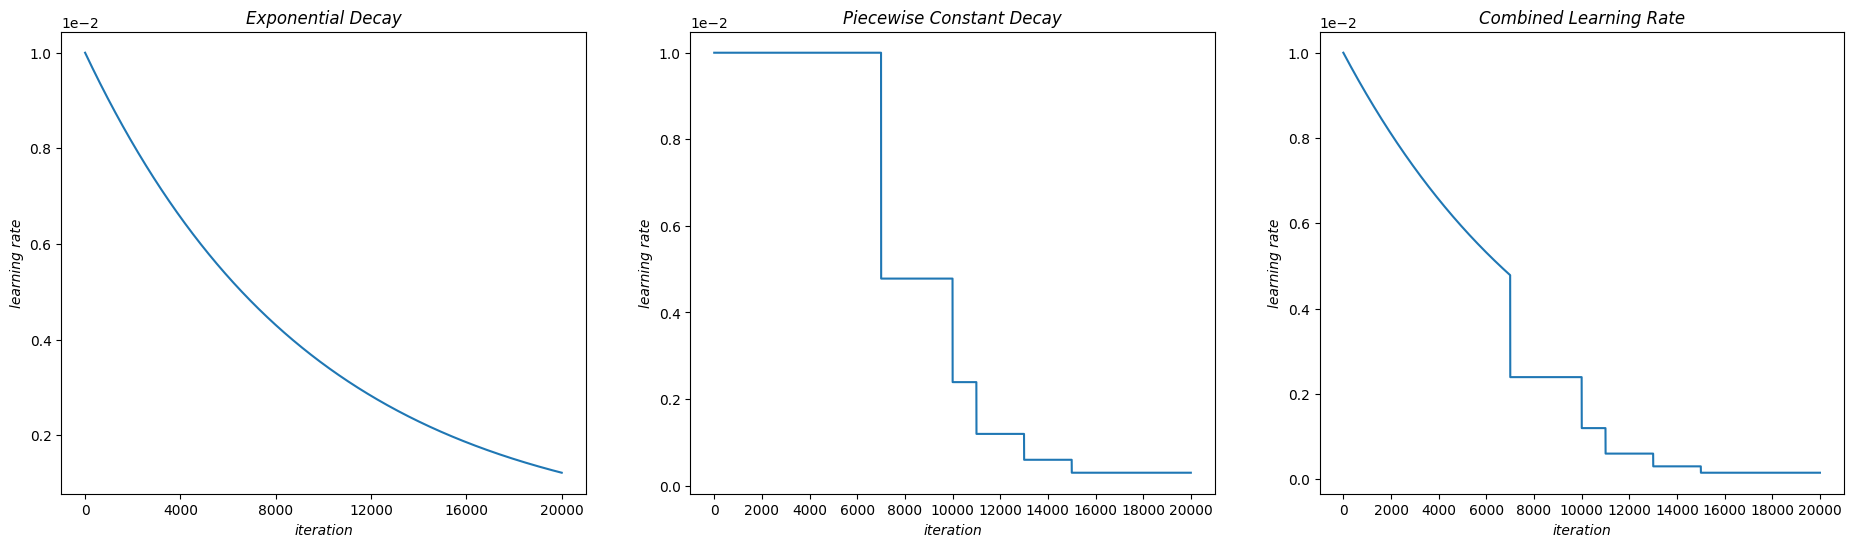

In [56]:
import numpy as np
import matplotlib.pyplot as plt

N = 20000  # Extended range

fig = plt.figure(figsize=(23, 6))

# ExponentialDecay
initial_learning_rate = lr_comb.initial_learning_rate
decay_steps = lr_comb.decay_steps
decay_rate = lr_comb.decay_rate

learning_rate = []
for i in range(N+1):
    lr = initial_learning_rate * decay_rate ** (i / decay_steps)
    learning_rate.append(lr)

plt.subplot(1, 3, 1)
plt.plot(learning_rate)
plt.xlabel('iteration', fontstyle='italic')
plt.ylabel('learning rate', fontstyle='italic')
plt.xticks(np.arange(0, N+1, 4000))
plt.ticklabel_format(axis='y', scilimits=(0, 0))
plt.title('Exponential Decay', y=1, fontstyle='italic')

# Piecewise Constant Decay
boundaries = lr_comb.boundaries
values = lr_comb.values

learning_rate = []
for i in range(N+1):
    for j in range(len(boundaries)):
        if i <= boundaries[0]:
            lr = lr_comb.initial_learning_rate
        elif i <= boundaries[j]:
            lr = values[j-1]
            break
        else:
            lr = values[-1]
    learning_rate.append(lr)

plt.subplot(1, 3, 2)
plt.plot(learning_rate)
plt.xlabel('iteration', fontstyle='italic')
plt.ylabel('learning rate', fontstyle='italic')
plt.xticks(np.arange(0, N+1, 2000))
plt.ticklabel_format(axis='y', scilimits=(0, 0))
plt.title('Piecewise Constant Decay', y=1, fontstyle='italic')

# Extended Combined Decay
boundaries = lr_comb.boundaries
values_steps = lr_comb.values_steps  # should be a list like [2, 2, 2, ...]
if isinstance(values_steps, int):
    values_steps = [values_steps] * (len(boundaries))  # Make uniform if scalar

i_stop = boundaries[0]
learning_rate = []

learning_rate = []
i_stop = boundaries[0]

for i in range(N+1):
    if i <= i_stop:
        lr = initial_learning_rate * decay_rate ** (i / decay_steps)
    else:
        for j in range(1, len(boundaries)):
            if boundaries[j-1] < i <= boundaries[j]:
                if i == boundaries[j-1] + 1:
                    # first step into this boundary: decay from previous segment
                    prev_lr = learning_rate[-1]
                    lr = prev_lr / values_steps[j-1]
                else:
                    lr = learning_rate[-1]  # maintain constant
                break
        else:
            # After the last boundary
            lr = learning_rate[-1] / values_steps[-1]
    learning_rate.append(lr)

plt.subplot(1, 3, 3)
plt.plot(learning_rate)
plt.xlabel('iteration', fontstyle='italic')
plt.ylabel('learning rate', fontstyle='italic')
plt.xticks(np.arange(0, N+1, 2000))
plt.ticklabel_format(axis='y', scilimits=(0,0))
plt.title('Combined Learning Rate', y=1, fontstyle='italic')



In [57]:
pred_lambda = [0.4973026660150758]


In [58]:
timeout = 1200
start_from = 1


models_Adam_comb = [None]*n_models
hists_Adam_comb = [None]*n_models
batch_size = 4096

for i in range(start_from - 1, n_models):
    models_Adam_comb[i] = []
    hists_Adam_comb[i] = []
    for j, lambd_val in enumerate(pred_lambda):
        print('{:s}\nModel Iteration: {:d}, Lambda Iteration: {:d}\n{:s}'.format(
            50*'-', i+1, j+1, 50*'-'))

        tf.random.set_seed(i + j)  # Use a combined seed for reproducibility

        # Build and initialize model
        models_Adam_comb[i].append(PINN_NeuralNet(lb, ub, **arch))
        models_Adam_comb[i][j].build(input_shape=(None, 3))

        # Set weights and lambda from base model
        models_Adam_comb[i][j].set_weights(models[i].get_weights())
        # Prepare optimizer
        optim_Adam_comb = tf.keras.optimizers.AdamW(learning_rate=lr_comb, weight_decay =1e-3)

        # Initialize solver
        solver = PINN_PDESolver(models_Adam_comb[i][j], X_train, fun_r_fwd, get_r_fwd,lambd_val)

        # Train the model
        print('\n\nAdam - Combined Learning Rate\n')
        solver.solve_with_TFoptimizer(optim_Adam_comb, X_train, u_train, W_u, W_v,timeout=timeout,batch_size=batch_size)

        # Store training history
        hists_Adam_comb[i].append(solver.hist)

        print('\n\n\n')

--------------------------------------------------
Model Iteration: 1, Lambda Iteration: 1
--------------------------------------------------


Adam - Combined Learning Rate



/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Streaming output truncated to the last 5000 lines.
PDE Loss: 1.00095079e-07 Data Loss: 0.0297179222 Total Loss: 0.297179312
PDE Loss: 9.81910233e-08 Data Loss: 0.0300601423 Total Loss: 0.300601512
PDE Loss: 1.06732053e-07 Data Loss: 0.0292775258 Total Loss: 0.292775393
PDE Loss: 1.02245657e-07 Data Loss: 0.0305442326 Total Loss: 0.305442423
PDE Loss: 9.95899825e-08 Data Loss: 0.0308177285 Total Loss: 0.308177382
PDE Loss: 1.08301286e-07 Data Loss: 0.0310098045 Total Loss: 0.310098171
PDE Loss: 1.07956957e-07 Data Loss: 0.0288450401 Total Loss: 0.288450509
PDE Loss: 9.31494952e-08 Data Loss: 0.0290037 Total Loss: 0.290037096
PDE Loss: 1.12802667e-07 Data Loss: 0.0302061811 Total Loss: 0.302061915
PDE Loss: 9.92583225e-08 Data Loss: 0.0297988616 Total Loss: 0.297988713
PDE Loss: 9.80453407e-08 Data Loss: 0.0293274969 Total Loss: 0.293275058
PDE Loss: 8.96308592e-08 Data Loss: 0.0292558149 Total Loss: 0.292558223
PDE Loss: 9.30832442e-08 Data Loss: 0.0306526199 Total Loss: 0.306526273
PDE

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_3', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Streaming output truncated to the last 5000 lines.
PDE Loss: 7.9525222e-08 Data Loss: 0.0322863869 Total Loss: 0.322863966
PDE Loss: 8.66306e-08 Data Loss: 0.0321582071 Total Loss: 0.321582168
PDE Loss: 1.05615548e-07 Data Loss: 0.0327512659 Total Loss: 0.327512771
PDE Loss: 9.36544708e-08 Data Loss: 0.033494547 Total Loss: 0.33494556
PDE Loss: 8.61806058e-08 Data Loss: 0.0307214148 Total Loss: 0.30721423
PDE Loss: 8.78862565e-08 Data Loss: 0.031402491 Total Loss: 0.314025
PDE Loss: 8.99063153e-08 Data Loss: 0.0289621931 Total Loss: 0.289622
PDE Loss: 1.01080666e-07 Data Loss: 0.0304005165 Total Loss: 0.304005265
PDE Loss: 9.14528897e-08 Data Loss: 0.0305165537 Total Loss: 0.305165619
PDE Loss: 8.94876706e-08 Data Loss: 0.0306017213 Total Loss: 0.306017309
PDE Loss: 1.05188334e-07 Data Loss: 0.0291250888 Total Loss: 0.291251
PDE Loss: 9.44447365e-08 Data Loss: 0.0312359948 Total Loss: 0.312360048
PDE Loss: 9.34151672e-08 Data Loss: 0.0313729681 Total Loss: 0.313729763
PDE Loss: 9.18237

In [59]:
path = dir + "CO_Model/GridedJabar_Fourier_tanh_fwd/"

In [60]:
for i in range(n_models):
  for j in range(len(pred_lambda)):
    models_Adam_comb[i][j].save_weights(path+"_"+str(i)+"_model_Adam_comb_"+str(j)+".weights.h5", 'h5')


for i in range(n_models):
  for j in range(len(pred_lambda)):
    np.savetxt(path + "loss/hist_Adam_comb_" + str(i) + "_" + str(j) + ".csv", hists_Adam_comb[i][j], delimiter=",")

In [67]:
n_models = 5

arch = {'output_dim':1, 'num_hidden_layers':5, 'num_neurons_per_layer':100,'activation':'tanh', 'trainable_B':True, 'sigmas':[1.0,2.0], 'mapping_size':64}

models = [None] * n_models

models_Adam_comb = [None]*n_models # Initialize models_Adam_comb with the correct size

for i in range(0, n_models):
    models_Adam_comb[i] = []
    for j in range(len(pred_lambda)):
        models_Adam_comb[i].append(PINN_NeuralNet(lb, ub, **arch))
        models_Adam_comb[i][j].build(input_shape=(None, 3))
        _ = models_Adam_comb[i][j](tf.zeros((1, 3)))
        models_Adam_comb[i][j].load_weights(
            path + "_" + str(i) + "_model_Adam_comb_" + str(j) + ".weights.h5"
        )


hists_Adam_comb = [None] * n_models

for i in range(0,n_models):
    hists_Adam_comb[i] = []
    for j in range(len(pred_lambda)):
        hists_Adam_comb[i].append(pd.read_csv(path + "/loss/hist_Adam_comb_" + str(i) + "_" + str(j) + ".csv",header=None))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_22', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_23', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_24', how

## Grafik Loss

len Atempt-0 Lambda ke- 0:  69
\\
len Atempt-1 Lambda ke- 0:  69
\\
len Atempt-2 Lambda ke- 0:  68
\\
len Atempt-3 Lambda ke- 0:  68
\\
len Atempt-4 Lambda ke- 0:  68
\\


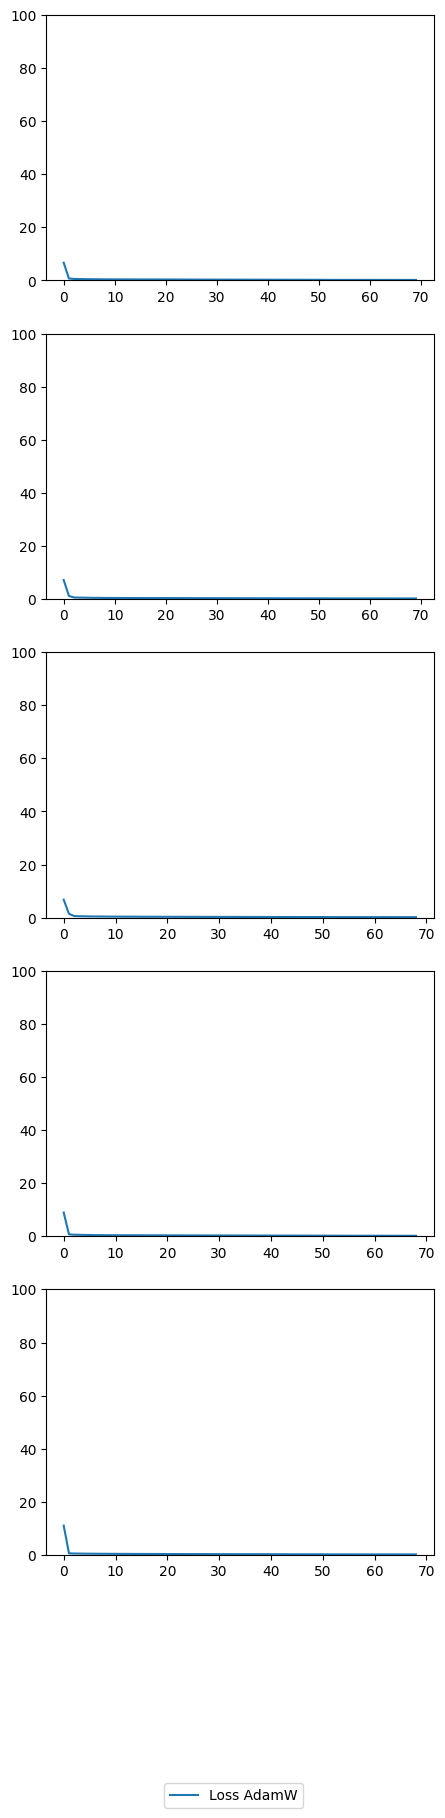

In [68]:
fig, axes = plt.subplots(nrows=n_models, ncols=len(pred_lambda), figsize=(5,20))

for i in range(n_models):
  for j in range(len(pred_lambda)):
    axes[i].plot(np.linspace(0, len(hists_Adam_comb[i][j]),len(hists_Adam_comb[i][j])), hists_Adam_comb[i][j])
    axes[i].set_ylim([0,100])
  # for j in range(len(pred_lambda)):
  #   axes[j].plot(np.linspace(0, len(hists_Adam_comb[i][j]),len(hists_Adam_comb[i][j])), hists_Adam_comb[i][j])
  #   axes[j].set_ylim([0,5e4])


    print(f"len Atempt-{i} Lambda ke- {j}: ",len(hists_Adam_comb[i][j]))
  print("\\\\")

  rows = ['Attempt {}'.format(row) for row in range(1, n_models+1)]

fig.legend(['Loss AdamW'], loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=True)

plt.show()

### Prediction and Evaluation

In [69]:
t_unique = np.sort(test_df['time'].unique())
x_unique = np.sort(test_df['x_coord'].unique())
y_unique = np.sort(test_df['y_coord'].unique())


In [70]:
lb = tf.constant(lb, dtype=tf.float32)
ub = tf.constant(ub, dtype=tf.float32)

In [71]:
train_Adam_comb = []


t_unique_train = np.sort(train_df['time'].unique())
x_unique_train = np.sort(train_df['x_coord'].unique())
y_unique_train = np.sort(train_df['y_coord'].unique())


for i in range(n_models):
  for j in range(len(pred_lambda)):
    train_Adam_comb.append(predict_solution(models_Adam_comb[i][j], X_train, t_unique_train, x_unique_train, y_unique_train))


df = pd.DataFrame(columns=['Adam'])
initial_lambdas = pred_lambda

# Evaluate and populate the DataFrame
for i in range(n_models):
    results = []
    for j in range(len(initial_lambdas)):
        # Evaluate solutions
        # eval_sgd = pinn.evaluate_solution(preds_SGD[i * len(initial_lambdas) + j], u_star)
        pred_t0 = train_Adam_comb[i * len(initial_lambdas) + j]
        eval_adam = evaluate_solution(pred_t0.numpy(), u_train.numpy())

        # Append results for each lambda
        # results.append(eval_sgd)
        results.append(eval_adam)

    # Add results to DataFrame
    df.loc[f'Attempt {i+1}'] = results

# Display the DataFrame
df


,Adam
Attempt 1,"(0.11216078, 3.6607637)"
Attempt 2,"(0.119084276, 3.8618464)"
Attempt 3,"(0.11064827, 3.5891042)"
Attempt 4,"(0.113819405, 3.6687667)"
Attempt 5,"(0.10994371, 3.5895262)"


In [72]:
def summarise_attempts(df: pd.DataFrame) -> pd.DataFrame:
    """
    Return a tidy table with mean, sample‑SD and CV
    for both numbers contained in each tuple cell.
    """
    summaries = {}
    for col in df.columns:
        arr = np.vstack(df[col].to_numpy())     # shape = (n_attempts, 2)
        μ  = arr.mean(axis=0)                   # mean
        σ  = arr.std(axis=0, ddof=1)            # sample SD (ddof=1)
        cv = σ / μ                              # coefficient of variation
        summaries[col] = {
            "mean_MAE": μ[0], "sd_MAE": σ[0], "cv_MAE": cv[0],
            "mean_MAPE": μ[1], "sd_MAPE": σ[1], "cv_MAPE": cv[1],
        }
    return pd.DataFrame(summaries).T

stats_df = summarise_attempts(df)
print(stats_df)

      mean_MAE    sd_MAE   cv_MAE  mean_MAPE   sd_MAPE  cv_MAPE
Adam  0.113131  0.003646  0.03223   3.674001  0.111615  0.03038


In [73]:
t_unique = np.sort(test_df['time'].unique())
x_unique = np.sort(test_df['x_coord'].unique())
y_unique = np.sort(test_df['y_coord'].unique())

preds_Adam_comb = []

for i in range(n_models):
  for j in range(len(pred_lambda)):
    preds_Adam_comb.append(predict_solution(models_Adam_comb[i][j], X_test, t_unique, x_unique, y_unique))


In [74]:
df = pd.DataFrame(columns=['Adam'])
initial_lambdas = pred_lambda

# Evaluate and populate the DataFrame
for i in range(n_models):
    results = []
    for j in range(len(initial_lambdas)):
        # Evaluate solutions
        # eval_sgd = pinn.evaluate_solution(preds_SGD[i * len(initial_lambdas) + j], u_star)
        pred_t0 = preds_Adam_comb[i * len(initial_lambdas) + j]
        eval_adam = evaluate_solution(pred_t0.numpy(), u_test.numpy())

        # Append results for each lambda
        # results.append(eval_sgd)
        results.append(eval_adam)

    # Add results to DataFrame
    df.loc[f'Attempt {i+1}'] = results

# Display the DataFrame
df


,Adam
Attempt 1,"(0.11335882, 3.6969616)"
Attempt 2,"(0.11997272, 3.8866055)"
Attempt 3,"(0.11188457, 3.625402)"
Attempt 4,"(0.11506755, 3.7048395)"
Attempt 5,"(0.11121674, 3.626864)"


In [75]:
def summarise_attempts(df: pd.DataFrame) -> pd.DataFrame:
    """
    Return a tidy table with mean, sample‑SD and CV
    for both numbers contained in each tuple cell.
    """
    summaries = {}
    for col in df.columns:
        arr = np.vstack(df[col].to_numpy())     # shape = (n_attempts, 2)
        μ  = arr.mean(axis=0)                   # mean
        σ  = arr.std(axis=0, ddof=1)            # sample SD (ddof=1)
        cv = σ / μ                              # coefficient of variation
        summaries[col] = {
            "mean_MAE": μ[0], "sd_MAE": σ[0], "cv_MAE": cv[0],
            "mean_MAPE": μ[1], "sd_MAPE": σ[1], "cv_MAPE": cv[1],
        }
    return pd.DataFrame(summaries).T

stats_df = summarise_attempts(df)
print(stats_df)

      mean_MAE  sd_MAE   cv_MAE  mean_MAPE  sd_MAPE   cv_MAPE
Adam    0.1143  0.0035  0.03062   3.708134  0.10658  0.028742


In [76]:
weights = models_Adam_comb[2][0].get_weights()

for i, w in enumerate(weights):
    print(f"Weight {i}: shape = {w.shape}")
    print(w)

Weight 0: shape = (3, 64)
[[-1.7125655   1.5445864  -1.030297    0.6819392   0.5130252  -0.8432082
  -0.02328292 -0.8107486   2.0104103   0.22464705 -0.8957061   1.227591
  -0.9977418  -1.0144738  -0.2240259  -1.6825653  -1.5776069  -0.3912544
   0.24075396 -0.41352928  1.416708    0.42217067  0.92225975 -0.25546095
  -0.5345136  -0.99261165 -1.2457922   0.43179166 -1.7508293   1.6752261
  -0.07281972 -0.81112915 -1.8182139  -1.1668087  -0.916693    1.0616373
   1.2218226  -1.5680952  -1.6724204   0.5301747   1.6539458  -0.5172639
   0.8793148  -1.1720387   0.6341559  -0.03151496 -0.11470811  1.3488768
  -0.7800867   1.1555135  -0.19442038  1.9978366   0.6678353  -0.20577146
   0.6409591  -0.881504    0.4256295  -1.5409489   0.95118743 -1.3148826
   0.40420341 -1.1721362  -1.456391    1.9962498 ]
 [ 0.6598117   0.6432517  -0.77576077  2.1421084  -2.3406174  -0.8253351
   0.07056222  0.62798005 -0.41382658  0.20399578 -0.68532944 -0.9391067
  -0.62442535  0.9514198  -1.0570226  -0.29350

# Rekonstruksi atau Imputasi

## Imputasi

In [ ]:
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import matplotlib as mpl
import matplotlib.patheffects as pe

df_CO_sea = pd.read_csv("/content/drive/My Drive/TA/Dataset/GridedJabar/CO_Sea_Grid_Jabar.csv")
df_CO_land = pd.read_csv("/content/drive/My Drive/TA/Dataset/GridedJabar/CO_Land_Grid_Jabar.csv")

df = pd.concat([ df_CO_land,df_CO_sea],axis=0)
df['date'] = pd.to_datetime(df['date'])
start_date = datetime(2023, 5, 1)

df=df.rename(columns={"mean_co":"CO_mean","latitude":"y_coord","longitude":"x_coord"})
df['time'] = (df['date'] - df['date'].min()).dt.days
df.x_coord = df.x_coord*100
df.y_coord = df.y_coord*100
df.sort_values(by=["time", "x_coord", "y_coord"], inplace=True)

In [ ]:
df

In [ ]:
missing_rows = df[(df["CO_mean"].isna()) | (df["CO_mean"] < 0)][["time", "x_coord", "y_coord"]]
missing_rows

# --- Convert to numpy for model input ---
X_missing = missing_rows.to_numpy(dtype=np.float32)

# --- Predict using your model ---
y_pred = models_Adam_comb[0][0].predict_on_batch(X_missing).reshape(-1)
y_pred = y_pred*1e-2
df.x_coord = df.x_coord/100
df.y_coord = df.y_coord/100
df_imputation = df.copy()

# --- Fill missing values ---
df_imputation.loc[(df_imputation["CO_mean"].isna()) | (df_imputation["CO_mean"] < 0), "CO_mean"] = y_pred

df_imputation.describe()

In [ ]:
df_imputation

## Rekonstruksi

In [ ]:
import numpy as np
import pandas as pd
import math
import os
from google.colab import files
from concurrent.futures import ThreadPoolExecutor

# --- 1. Load data dan siapkan grid (1e-4 spacing) ---

# Misal Anda sudah memiliki filtered_df
# Jika belum, upload:
# uploaded = files.upload()
# filtered_df = pd.read_csv("filtered_df.csv")

step = 1  # Resolusi

t_min, t_max = filtered_df["time"].min(), filtered_df["time"].max()
x_min, x_max = filtered_df["x_coord"].min(), filtered_df["x_coord"].max()
y_min, y_max = filtered_df["y_coord"].min(), filtered_df["y_coord"].max()

t_points = np.arange(t_min, t_max + step, 1, dtype=np.float32)
x_points = np.arange(x_min, x_max + step, step, dtype=np.float32)
y_points = np.arange(y_min, y_max + step, step, dtype=np.float32)


# --- 2. Pilih model dan path hasil ---
target_indices = [(0, 0)]  # sesuaikan
models_to_use  = [models_Adam_comb[i][j] for i, j in target_indices]
model_labels   = [f"m{i}_{j}" for i, j in target_indices]
file_paths     = [f"/content/Softplus_CO_GridedJabar_M3_tanh_prediction_{label}.csv" for label in model_labels]

# --- 3. Buat file output kosong dengan header ---
for path in file_paths:
    if os.path.exists(path):
        os.remove(path)
    with open(path, "w") as f:
        f.write("t,x,y,prediction\n")

# --- 4. Precompute spatial meshgrid (xy pairs) sekali saja ---
xy_pairs = np.stack(np.meshgrid(x_points, y_points, indexing="ij"), -1).reshape(-1, 2)

# --- 5. Fungsi batch generator ---
def gen_batches(t_vec, batch_size=1_000_000):
    for t in t_vec:
        t_col = np.full((xy_pairs.shape[0], 1), t, dtype=np.float32)
        tx_y = np.hstack([t_col, xy_pairs])
        n_rows = tx_y.shape[0]
        n_batch = math.ceil(n_rows / batch_size)
        for k in range(n_batch):
            yield t, tx_y[k * batch_size : (k + 1) * batch_size]

# --- 6. Fungsi prediksi + tulis ke file ---
def predict_and_write(model, batch, path):
    pred = model.predict_on_batch(batch).reshape(-1, 1)
    output = np.hstack([batch, pred])
    df = pd.DataFrame(output, columns=["t", "x", "y", "prediction"])
    df.to_csv(path, mode="a", header=False, index=False, float_format="%.6g")

# --- 7. Loop utama: batch per waktu + paralel tulis model ---
for t_val, batch in gen_batches(t_points):
    print(f"Processing time: {t_val}, Batch shape: {batch.shape}")
    with ThreadPoolExecutor() as executor:
        for model, path in zip(models_to_use, file_paths):
            executor.submit(predict_and_write, model, batch, path)

In [ ]:
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import matplotlib as mpl
import matplotlib.patheffects as pe

# prediction_df =pd.read_csv(dir+"Reconstruction/CO/Softplus_CO_GridedJabar_M3_tanh_prediction_m1_0.csv")
prediction_df =pd.read_csv(dir+"Reconstruction/Jabar/Softplus_CO_GridedJabar_M3_tanh_prediction_m0_0.csv")

prediction_cleaned_df =prediction_df.copy()
prediction_cleaned_df['prediction'] = prediction_df['prediction'].apply(lambda x: 0 if x < 0 else x)
prediction_df['prediction']= prediction_df['prediction']*1e-2
prediction_df['x'] = prediction_df['x']/100
prediction_df['y'] = prediction_df['y']/100

In [ ]:
prediction_df.describe()

In [ ]:
prediction_df[prediction_df.prediction<0]

In [ ]:
prediction_df

In [ ]:
# Load shapefile of Indonesia level-2
indonesia = gpd.read_file('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_IDN_2.json')

# Create geometry column in df
df['geometry'] = [Point(xy) for xy in zip(df['x_coord'], df['y_coord'])]
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326')


jawa_prov = ['JakartaRaya', 'JawaBarat','Banten']
jawa = indonesia[indonesia['NAME_1'].isin(jawa_prov)]
jawa['centroid'] = jawa.geometry.centroid

In [ ]:
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import pandas as pd

# --- Step 1: Define the start date ---
start_date = datetime(2023, 5, 1)  # Fixed starting date

# --- Step 2: Input your target date ---
target_day = 6
target_month = 10
target_year = 2024
target_date = datetime(target_year, target_month, target_day)

# --- Step 3: Prepare geographical data (Bangkok) ---
indonesia = gpd.read_file('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_IDN_2.json')

jawa_provinces = ['Tangerang', 'Bogor', 'KotaTangerang', 'JakartaBarat',
       'JakartaUtara', 'JakartaSelatan', 'KotaBogor',
       'Depok', 'JakartaPusat', 'JakartaTimur', 'Bekasi',
       'KotaBekasi','TangerangSelatan']
jawa = indonesia[indonesia['NAME_2'].isin(jawa_provinces)]
jawa['centroid'] = jawa.geometry.centroid

# --- Step 4: Create 4 consecutive days ---
dates = [target_date + timedelta(days=i) for i in [0,7,14,21]]

# --- Step 5: Plot in 2×2 frame ---
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()

for i, day_offset in enumerate([0,7,14,21]):
    time_to_visualize = t + day_offset

    df_visualize = prediction_df[prediction_df['t'] == time_to_visualize].copy()
    ax = axes[i]

    if df_visualize.empty:
        ax.set_title(f"No data for t+{day_offset} ({(target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')})")
        ax.axis('off')
        continue

    geometry = [Point(xy) for xy in zip(df_visualize['x'], df_visualize['y'])]
    gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)

    merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")

    jawa.plot(ax=ax, color='lightgray', edgecolor='black')
    jawa.boundary.plot(ax=ax, color='black', linewidth=1)

    if not merged_gdf.empty:
        merged_gdf.plot(column='prediction', ax=ax, legend=True, cmap='viridis', legend_kwds={'label': "Prediksi CO", 'orientation': "horizontal"})

    # Add city names
    for idx, row in jawa.iterrows():
        ax.annotate(
            text=row['NAME_2'],
            xy=(row['centroid'].x, row['centroid'].y),
            ha='center', fontsize=10, color='black', weight='bold'
        )

    # Titles & limits
    ax.set_title(f"CO - {(target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')}", fontsize=16)
    ax.set_xlabel("Bujur")
    ax.set_ylabel("Lintang")

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

# Lebaran 2024 (8 April - 12 April 2024)

In [ ]:

# --- Step 2: Input your target date ---
target_day = 8
target_month = 4
target_year = 2024
target_date = datetime(target_year, target_month, target_day)

t = (target_date - start_date).days
print("t =", t)

# --- Step 3: Load Indonesia shapefile ---
# indonesia = gpd.read_file('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_IDN_2.json')

# jawa_provinces = ['Tangerang', 'Bogor', 'KotaTangerang', 'JakartaBarat',
#        'JakartaUtara', 'JakartaSelatan', 'KotaBogor',
#        'Depok', 'JakartaPusat', 'JakartaTimur', 'Bekasi',
#        'KotaBekasi','TangerangSelatan']
# jawa = indonesia[indonesia['NAME_2'].isin(jawa_provinces)]
# jawa['centroid'] = jawa.geometry.centroid

# --- Step 4: Define the offsets you want to compare ---
day_offsets = [0,1,2]


# --- Step 5: Setup figure---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(7.8 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}
vmin, vmax = 1.1e-2, 4.1e-2

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Actual Data"), (df_imputation, "Imputed Data")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")

        jawa.plot(ax=ax, color='lightgray', edgecolor='black')
        jawa.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
                cmap='viridis',
                vmin=vmin, vmax=vmax
            )
            mappables[label] = mappable

        # # City names
        # for idx, row in jawa.iterrows():
        #     ax.annotate(
        #         text=row['NAME_2'],
        #         xy=(row['centroid'].x, row['centroid'].y),
        #         ha='center', fontsize=7, color='black',
        #         # path_effects=[pe.withStroke(linewidth=1, foreground="white")]
        #     )

        ax.set_title(f"{label} of CO on {date_label}", fontsize=12, pad=6)
        ax.set_ylim(ymax=-5.8,ymin=-7.9)
        ax.set_xlabel("Longitude", fontsize=12, labelpad=2)
        ax.set_ylabel("Latitude", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Concentration", fontsize=12)
cbar1.ax.tick_params(labelsize=13,pad=6)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Concentration", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


In [ ]:
from matplotlib.colors import LinearSegmentedColormap

viridis = plt.cm.viridis(np.linspace(0, 1, 256))
# Define a smooth gradient from yellow to orange to red (HSV-based blending)
yellow_to_red = np.array([
    [253/255, 231/255, 37/255, 1],  # #FDE725
    [1.0, 0.65, 0.0, 1.0],  # orange
    [1.0, 0.0, 0.0, 1.0]    # red
])
n_extend = int(256 * 0.25)

colors = np.vstack((
    viridis,
    np.linspace(yellow_to_red[0], yellow_to_red[-1], n_extend)
))

# Create the final colormap
viridis_to_red = LinearSegmentedColormap.from_list(
    "viridis_yellow_orange_red", colors
)



# --- Step 2: Input your target date ---
target_day = 8
target_month = 4
target_year = 2024
target_date = datetime(target_year, target_month, target_day)

t = (target_date - start_date).days
print("t =", t)

# --- Step 3: Load Indonesia shapefile ---
# indonesia = gpd.read_file('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_IDN_2.json')

# jawa_provinces = ['Tangerang', 'Bogor', 'KotaTangerang', 'JakartaBarat',
#        'JakartaUtara', 'JakartaSelatan', 'KotaBogor',
#        'Depok', 'JakartaPusat', 'JakartaTimur', 'Bekasi',
#        'KotaBekasi','TangerangSelatan']
# jawa = indonesia[indonesia['NAME_2'].isin(jawa_provinces)]
# jawa['centroid'] = jawa.geometry.centroid

# --- Step 4: Define the offsets you want to compare ---
day_offsets = [0,1,2]


# --- Step 5: Setup figure---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(7.8 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}
vmin, vmax = 1.1e-2, 4.1e-2

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Actual Data"), (df_imputation, "Imputed Data")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")

        jawa.plot(ax=ax, color='lightgray', edgecolor='black')
        jawa.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
                cmap=viridis_to_red,
                vmin=vmin, vmax=vmax
            )
            mappables[label] = mappable

        # # City names
        # for idx, row in jawa.iterrows():
        #     ax.annotate(
        #         text=row['NAME_2'],
        #         xy=(row['centroid'].x, row['centroid'].y),
        #         ha='center', fontsize=7, color='black',
        #         # path_effects=[pe.withStroke(linewidth=1, foreground="white")]
        #     )

        ax.set_title(f"{label} of CO on {date_label}", fontsize=12, pad=6)
        ax.set_ylim(ymax=-5.8,ymin=-7.9)
        ax.set_xlabel("Longitude", fontsize=12, labelpad=2)
        ax.set_ylabel("Latitude", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap=viridis_to_red, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Concentration", fontsize=12)
cbar1.ax.tick_params(labelsize=13,pad=6)

sm2 = mpl.cm.ScalarMappable(cmap=viridis_to_red, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Concentration", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


In [ ]:
# --- Step 5: Setup figure---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(7.8 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Data Asli"), (df_imputation, "Data Imputasi")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")

        jawa.plot(ax=ax, color='lightgray', edgecolor='black')
        jawa.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
               cmap='viridis',
              vmin=vmin, vmax=vmax

            )
            mappables[label] = mappable

        # # City names
        # for idx, row in jawa.iterrows():
        #     ax.annotate(
        #         text=row['NAME_2'],
        #         xy=(row['centroid'].x, row['centroid'].y),
        #         ha='center', fontsize=7, color='black'
        #         # path_effects=[pe.withStroke(linewidth=1, foreground="white")]
        #     )

        ax.set_title(f"{label} CO pada {date_label}", fontsize=12, pad=6)
        ax.set_ylim(ymax=-5.8,ymin=-7.9)
        ax.set_xlabel("Bujur", fontsize=12, labelpad=2)
        ax.set_ylabel("Lintang", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Konsentrasi Polutan", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Konsentrasi Polutan", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


In [ ]:
# --- Step 5: Setup figure---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(7.8 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Data Asli"), (df_imputation, "Data Imputasi")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")

        jawa.plot(ax=ax, color='lightgray', edgecolor='black')
        jawa.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
               cmap=viridis_to_red,
              vmin=vmin, vmax=vmax

            )
            mappables[label] = mappable

        # # City names
        # for idx, row in jawa.iterrows():
        #     ax.annotate(
        #         text=row['NAME_2'],
        #         xy=(row['centroid'].x, row['centroid'].y),
        #         ha='center', fontsize=7, color='black'
        #         # path_effects=[pe.withStroke(linewidth=1, foreground="white")]
        #     )

        ax.set_title(f"{label} CO pada {date_label}", fontsize=12, pad=6)
        ax.set_ylim(ymax=-5.8,ymin=-7.9)
        ax.set_xlabel("Bujur", fontsize=12, labelpad=2)
        ax.set_ylabel("Lintang", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap=viridis_to_red, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Konsentrasi Polutan", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap=viridis_to_red, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Konsentrasi Polutan", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


In [ ]:

predict = prediction_df.copy()
predict = predict.rename(columns={'prediction':'CO_mean','t':'time','x':'x_coord','y':'y_coord'})

# --- Step 2: Input your target date ---
target_day = 8
target_month = 4
target_year = 2024
target_date = datetime(target_year, target_month, target_day)

t = (target_date - start_date).days
print("t =", t)

# # --- Step 3: Load Indonesia shapefile ---
# indonesia = gpd.read_file('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_IDN_2.json')

# jawa_provinces = ['Tangerang', 'Bogor', 'KotaTangerang', 'JakartaBarat',
#        'JakartaUtara', 'JakartaSelatan', 'KotaBogor',
#        'Depok', 'JakartaPusat', 'JakartaTimur', 'Bekasi',
#        'KotaBekasi','TangerangSelatan']
# jawa = indonesia[indonesia['NAME_2'].isin(jawa_provinces)]
# jawa['centroid'] = jawa.geometry.centroid


# --- Step 5: Setup figure (rows = dates, cols = 2 for df & df_imputation) ---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(7.8 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Actual Data"), (prediction, "Reconstructed Data")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")

        jawa.plot(ax=ax, color='lightgray', edgecolor='black')
        jawa.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
               cmap='viridis',  vmin=vmin, vmax=vmax

            )
            mappables[label] = mappable

        # # City names
        # for idx, row in jawa.iterrows():
        #     ax.annotate(
        #         text=row['NAME_2'],
        #         xy=(row['centroid'].x, row['centroid'].y),
        #         ha='center', fontsize=7, color='black',
        #         # path_effects=[pe.withStroke(linewidth=1.2, foreground="white")]
        #     )

        ax.set_title(f"{label} of CO on {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Longitude", fontsize=12, labelpad=2)
        ax.set_ylabel("Latitude", fontsize=12, labelpad=2)
        ax.set_ylim(ymax=-5.8,ymin=-7.9)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Concentration", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Concentration", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


In [ ]:

predict = prediction_df.copy()
predict = predict.rename(columns={'prediction':'CO_mean','t':'time','x':'x_coord','y':'y_coord'})

# --- Step 2: Input your target date ---
target_day = 8
target_month = 4
target_year = 2024
target_date = datetime(target_year, target_month, target_day)

t = (target_date - start_date).days
print("t =", t)

# # --- Step 3: Load Indonesia shapefile ---
# indonesia = gpd.read_file('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_IDN_2.json')

# jawa_provinces = ['Tangerang', 'Bogor', 'KotaTangerang', 'JakartaBarat',
#        'JakartaUtara', 'JakartaSelatan', 'KotaBogor',
#        'Depok', 'JakartaPusat', 'JakartaTimur', 'Bekasi',
#        'KotaBekasi','TangerangSelatan']
# jawa = indonesia[indonesia['NAME_2'].isin(jawa_provinces)]
# jawa['centroid'] = jawa.geometry.centroid


# --- Step 5: Setup figure (rows = dates, cols = 2 for df & df_imputation) ---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(7.8 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Actual Data"), (predict, "Reconstructed Data")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")

        jawa.plot(ax=ax, color='lightgray', edgecolor='black')
        jawa.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
               cmap=viridis_to_red,  vmin=vmin, vmax=vmax

            )
            mappables[label] = mappable

        # # City names
        # for idx, row in jawa.iterrows():
        #     ax.annotate(
        #         text=row['NAME_2'],
        #         xy=(row['centroid'].x, row['centroid'].y),
        #         ha='center', fontsize=7, color='black',
        #         # path_effects=[pe.withStroke(linewidth=1.2, foreground="white")]
        #     )

        ax.set_title(f"{label} of CO on {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Longitude", fontsize=12, labelpad=2)
        ax.set_ylabel("Latitude", fontsize=12, labelpad=2)
        ax.set_ylim(ymax=-5.8,ymin=-7.9)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap=viridis_to_red, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Concentration", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap=viridis_to_red, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Concentration", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


In [ ]:
# --- Step 5: Setup figure---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(7.8 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Data Asli"), (prediction, "Data Rekonstruksi")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")

        jawa.plot(ax=ax, color='lightgray', edgecolor='black')
        jawa.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
                cmap='viridis', vmin=vmin, vmax=vmax
            )
            mappables[label] = mappable

        # # City names
        # for idx, row in jawa.iterrows():
        #     ax.annotate(
        #         text=row['NAME_2'],
        #         xy=(row['centroid'].x, row['centroid'].y),
        #         ha='center', fontsize=10, color='black', weight='bold',
        #         path_effects=[pe.withStroke(linewidth=1.2, foreground="white")]
        #     )

        ax.set_title(f"{label} CO pada {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Bujur", fontsize=12, labelpad=2)
        ax.set_ylabel("Lintang", fontsize=12, labelpad=2)
        ax.set_ylim(ymax=-5.8,ymin=-7.9)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Konsentrasi Polutan", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Konsentrasi Polutan", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


In [ ]:
# --- Step 5: Setup figure---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(7.8 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Data Asli"), (predict, "Data Rekonstruksi")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")

        jawa.plot(ax=ax, color='lightgray', edgecolor='black')
        jawa.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
                cmap=viridis_to_red, vmin=vmin, vmax=vmax
            )
            mappables[label] = mappable

        # # City names
        # for idx, row in jawa.iterrows():
        #     ax.annotate(
        #         text=row['NAME_2'],
        #         xy=(row['centroid'].x, row['centroid'].y),
        #         ha='center', fontsize=10, color='black', weight='bold',
        #         path_effects=[pe.withStroke(linewidth=1.2, foreground="white")]
        #     )

        ax.set_title(f"{label} CO pada {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Bujur", fontsize=12, labelpad=2)
        ax.set_ylabel("Lintang", fontsize=12, labelpad=2)
        ax.set_ylim(ymax=-5.8,ymin=-7.9)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap=viridis_to_red, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Konsentrasi Polutan", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap=viridis_to_red, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Konsentrasi Polutan", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


In [ ]:

# --- Step 2: Input your target date ---
target_day = 11
target_month = 4
target_year = 2024
target_date = datetime(target_year, target_month, target_day)

t = (target_date - start_date).days
print("t =", t)

# --- Step 3: Load Indonesia shapefile ---
# indonesia = gpd.read_file('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_IDN_2.json')

# jawa_provinces = ['Tangerang', 'Bogor', 'KotaTangerang', 'JakartaBarat',
#        'JakartaUtara', 'JakartaSelatan', 'KotaBogor',
#        'Depok', 'JakartaPusat', 'JakartaTimur', 'Bekasi',
#        'KotaBekasi','TangerangSelatan']
# jawa = indonesia[indonesia['NAME_2'].isin(jawa_provinces)]
# jawa['centroid'] = jawa.geometry.centroid

# --- Step 4: Define the offsets you want to compare ---
day_offsets = [0,1,2]


# --- Step 5: Setup figure---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(7.8 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Actual Data"), (df_imputation, "Imputed Data")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")

        jawa.plot(ax=ax, color='lightgray', edgecolor='black')
        jawa.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
                cmap='viridis', vmin=vmin, vmax=vmax
            )
            mappables[label] = mappable

        # # City names
        # for idx, row in jawa.iterrows():
        #     ax.annotate(
        #         text=row['NAME_2'],
        #         xy=(row['centroid'].x, row['centroid'].y),
        #         ha='center', fontsize=10, color='black', weight='bold',
        #         path_effects=[pe.withStroke(linewidth=1.2, foreground="white")]
        #     )

        ax.set_title(f"{label} of CO on {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Longitude", fontsize=12, labelpad=2)
        ax.set_ylabel("Latitude", fontsize=12, labelpad=2)
        ax.set_ylim(ymax=-5.8,ymin=-7.9)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Concentration", fontsize=12)
cbar1.ax.tick_params(labelsize=13,pad=6)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Concentration", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


In [ ]:

# --- Step 2: Input your target date ---
target_day = 11
target_month = 4
target_year = 2024
target_date = datetime(target_year, target_month, target_day)

t = (target_date - start_date).days
print("t =", t)

# --- Step 3: Load Indonesia shapefile ---
# indonesia = gpd.read_file('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_IDN_2.json')

# jawa_provinces = ['Tangerang', 'Bogor', 'KotaTangerang', 'JakartaBarat',
#        'JakartaUtara', 'JakartaSelatan', 'KotaBogor',
#        'Depok', 'JakartaPusat', 'JakartaTimur', 'Bekasi',
#        'KotaBekasi','TangerangSelatan']
# jawa = indonesia[indonesia['NAME_2'].isin(jawa_provinces)]
# jawa['centroid'] = jawa.geometry.centroid

# --- Step 4: Define the offsets you want to compare ---
day_offsets = [0,1,2]


# --- Step 5: Setup figure---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(7.8 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Actual Data"), (df_imputation, "Imputed Data")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")

        jawa.plot(ax=ax, color='lightgray', edgecolor='black')
        jawa.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
                cmap=viridis_to_red, vmin=vmin, vmax=vmax
            )
            mappables[label] = mappable

        # # City names
        # for idx, row in jawa.iterrows():
        #     ax.annotate(
        #         text=row['NAME_2'],
        #         xy=(row['centroid'].x, row['centroid'].y),
        #         ha='center', fontsize=10, color='black', weight='bold',
        #         path_effects=[pe.withStroke(linewidth=1.2, foreground="white")]
        #     )

        ax.set_title(f"{label} of CO on {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Longitude", fontsize=12, labelpad=2)
        ax.set_ylabel("Latitude", fontsize=12, labelpad=2)
        ax.set_ylim(ymax=-5.8,ymin=-7.9)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap=viridis_to_red, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Concentration", fontsize=12)
cbar1.ax.tick_params(labelsize=13,pad=6)

sm2 = mpl.cm.ScalarMappable(cmap=viridis_to_red, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Concentration", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


In [ ]:
# --- Step 5: Setup figure---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(7.8 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Data Asli"), (df_imputation, "Data Imputasi")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")

        jawa.plot(ax=ax, color='lightgray', edgecolor='black')
        jawa.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
               cmap='viridis', vmin=vmin, vmax=vmax
            )
            mappables[label] = mappable

        # # City names
        # for idx, row in jawa.iterrows():
        #     ax.annotate(
        #         text=row['NAME_2'],
        #         xy=(row['centroid'].x, row['centroid'].y),
        #         ha='center', fontsize=10, color='black', weight='bold',
        #         path_effects=[pe.withStroke(linewidth=1.2, foreground="white")]
        #     )

        ax.set_title(f"{label} CO pada {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Bujur", fontsize=12, labelpad=2)
        ax.set_ylabel("Lintang", fontsize=12, labelpad=2)
        ax.set_ylim(ymax=-5.8,ymin=-7.9)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Konsentrasi Polutan", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Konsentrasi Polutan", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


In [ ]:
# --- Step 5: Setup figure---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(7.8 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Data Asli"), (df_imputation, "Data Imputasi")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")

        jawa.plot(ax=ax, color='lightgray', edgecolor='black')
        jawa.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
               cmap=viridis_to_red, vmin=vmin, vmax=vmax
            )
            mappables[label] = mappable

        # # City names
        # for idx, row in jawa.iterrows():
        #     ax.annotate(
        #         text=row['NAME_2'],
        #         xy=(row['centroid'].x, row['centroid'].y),
        #         ha='center', fontsize=10, color='black', weight='bold',
        #         path_effects=[pe.withStroke(linewidth=1.2, foreground="white")]
        #     )

        ax.set_title(f"{label} CO pada {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Bujur", fontsize=12, labelpad=2)
        ax.set_ylabel("Lintang", fontsize=12, labelpad=2)
        ax.set_ylim(ymax=-5.8,ymin=-7.9)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap=viridis_to_red, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Konsentrasi Polutan", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap=viridis_to_red, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Konsentrasi Polutan", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


In [ ]:

predict = prediction_df.copy()
predict = predict.rename(columns={'prediction':'CO_mean','t':'time','x':'x_coord','y':'y_coord'})


# --- Step 5: Setup figure (rows = dates, cols = 2 for df & df_imputation) ---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(7.8 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Actual Data"), (prediction, "Reconstructed Data")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")

        jawa.plot(ax=ax, color='lightgray', edgecolor='black')
        jawa.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
               cmap='viridis', vmin=vmin, vmax=vmax
            )
            mappables[label] = mappable

        # # City names
        # for idx, row in jawa.iterrows():
        #     ax.annotate(
        #         text=row['NAME_2'],
        #         xy=(row['centroid'].x, row['centroid'].y),
        #         ha='center', fontsize=10, color='black', weight='bold',
        #         path_effects=[pe.withStroke(linewidth=1.2, foreground="white")]
        #     )

        ax.set_title(f"{label} of CO on {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Longitude", fontsize=12, labelpad=2)
        ax.set_ylabel("Latitude", fontsize=12, labelpad=2)
        ax.set_ylim(ymax=-5.8,ymin=-7.9)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Concentration", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Concentration", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


In [ ]:

predict = prediction_df.copy()
predict = predict.rename(columns={'prediction':'CO_mean','t':'time','x':'x_coord','y':'y_coord'})


# --- Step 5: Setup figure (rows = dates, cols = 2 for df & df_imputation) ---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(7.8 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Actual Data"), (predict, "Reconstructed Data")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")

        jawa.plot(ax=ax, color='lightgray', edgecolor='black')
        jawa.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
               cmap= viridis_to_red, vmin=vmin, vmax=vmax
            )
            mappables[label] = mappable

        # # City names
        # for idx, row in jawa.iterrows():
        #     ax.annotate(
        #         text=row['NAME_2'],
        #         xy=(row['centroid'].x, row['centroid'].y),
        #         ha='center', fontsize=10, color='black', weight='bold',
        #         path_effects=[pe.withStroke(linewidth=1.2, foreground="white")]
        #     )

        ax.set_title(f"{label} of CO on {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Longitude", fontsize=12, labelpad=2)
        ax.set_ylabel("Latitude", fontsize=12, labelpad=2)
        ax.set_ylim(ymax=-5.8,ymin=-7.9)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap=viridis_to_red, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Concentration", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap=viridis_to_red, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Concentration", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


In [ ]:
# --- Step 5: Setup figure---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(7.8 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Data Asli"), (prediction, "Data Rekonstruksi")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")

        jawa.plot(ax=ax, color='lightgray', edgecolor='black')
        jawa.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
                cmap='viridis', vmin=vmin, vmax=vmax
            )
            mappables[label] = mappable

        # # City names
        # for idx, row in jawa.iterrows():
        #     ax.annotate(
        #         text=row['NAME_2'],
        #         xy=(row['centroid'].x, row['centroid'].y),
        #         ha='center', fontsize=10, color='black', weight='bold',
        #         path_effects=[pe.withStroke(linewidth=1.2, foreground="white")]
        #     )

        ax.set_title(f"{label} CO pada {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Bujur", fontsize=12, labelpad=2)
        ax.set_ylabel("Lintang", fontsize=12, labelpad=2)
        ax.set_ylim(ymax=-5.8,ymin=-7.9)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Konsentrasi Polutan", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Konsentrasi Polutan", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


In [ ]:
# --- Step 5: Setup figure---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(7.8 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Data Asli"), (predict, "Data Rekonstruksi")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")

        jawa.plot(ax=ax, color='lightgray', edgecolor='black')
        jawa.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
                cmap=viridis_to_red, vmin=vmin, vmax=vmax
            )
            mappables[label] = mappable

        # # City names
        # for idx, row in jawa.iterrows():
        #     ax.annotate(
        #         text=row['NAME_2'],
        #         xy=(row['centroid'].x, row['centroid'].y),
        #         ha='center', fontsize=10, color='black', weight='bold',
        #         path_effects=[pe.withStroke(linewidth=1.2, foreground="white")]
        #     )

        ax.set_title(f"{label} CO pada {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Bujur", fontsize=12, labelpad=2)
        ax.set_ylabel("Lintang", fontsize=12, labelpad=2)
        ax.set_ylim(ymax=-5.8,ymin=-7.9)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap=viridis_to_red, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Konsentrasi Polutan", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap=viridis_to_red, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Konsentrasi Polutan", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


# Lebaran 2025 (30 Maret - 4 April 2025)

In [ ]:

# --- Step 2: Input your target date ---
target_day = 29
target_month = 3
target_year = 2025
target_date = datetime(target_year, target_month, target_day)

t = (target_date - start_date).days
print("t =", t)

# --- Step 3: Load Indonesia shapefile ---
# indonesia = gpd.read_file('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_IDN_2.json')

# jawa_provinces = ['Tangerang', 'Bogor', 'KotaTangerang', 'JakartaBarat',
#        'JakartaUtara', 'JakartaSelatan', 'KotaBogor',
#        'Depok', 'JakartaPusat', 'JakartaTimur', 'Bekasi',
#        'KotaBekasi','TangerangSelatan']
# jawa = indonesia[indonesia['NAME_2'].isin(jawa_provinces)]
# jawa['centroid'] = jawa.geometry.centroid

# --- Step 4: Define the offsets you want to compare ---
day_offsets = [0,1,2]


# --- Step 5: Setup figure---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(7.8 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}
vmin, vmax = 1.5e-2, 3.1e-2

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Actual Data"), (df_imputation, "Imputed Data")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")

        jawa.plot(ax=ax, color='lightgray', edgecolor='black')
        jawa.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
                cmap='viridis',
                vmin=vmin, vmax=vmax
            )
            mappables[label] = mappable

        # # City names
        # for idx, row in jawa.iterrows():
        #     ax.annotate(
        #         text=row['NAME_2'],
        #         xy=(row['centroid'].x, row['centroid'].y),
        #         ha='center', fontsize=7, color='black',
        #         # path_effects=[pe.withStroke(linewidth=1, foreground="white")]
        #     )

        ax.set_title(f"{label} of CO on {date_label}", fontsize=12, pad=6)
        ax.set_ylim(ymax=-5.8,ymin=-7.9)
        ax.set_xlabel("Longitude", fontsize=12, labelpad=2)
        ax.set_ylabel("Latitude", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Concentration", fontsize=12)
cbar1.ax.tick_params(labelsize=13,pad=6)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Concentration", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()



In [ ]:

# --- Step 2: Input your target date ---
target_day = 29
target_month = 3
target_year = 2025
target_date = datetime(target_year, target_month, target_day)

t = (target_date - start_date).days
print("t =", t)

# --- Step 3: Load Indonesia shapefile ---
# indonesia = gpd.read_file('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_IDN_2.json')

# jawa_provinces = ['Tangerang', 'Bogor', 'KotaTangerang', 'JakartaBarat',
#        'JakartaUtara', 'JakartaSelatan', 'KotaBogor',
#        'Depok', 'JakartaPusat', 'JakartaTimur', 'Bekasi',
#        'KotaBekasi','TangerangSelatan']
# jawa = indonesia[indonesia['NAME_2'].isin(jawa_provinces)]
# jawa['centroid'] = jawa.geometry.centroid

# --- Step 4: Define the offsets you want to compare ---
day_offsets = [0,1,2]


# --- Step 5: Setup figure---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(7.8 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}
vmin, vmax = 1.5e-2, 3.1e-2

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Actual Data"), (df_imputation, "Imputed Data")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")

        jawa.plot(ax=ax, color='lightgray', edgecolor='black')
        jawa.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
                cmap=viridis_to_red,
                vmin=vmin, vmax=vmax
            )
            mappables[label] = mappable

        # # City names
        # for idx, row in jawa.iterrows():
        #     ax.annotate(
        #         text=row['NAME_2'],
        #         xy=(row['centroid'].x, row['centroid'].y),
        #         ha='center', fontsize=7, color='black',
        #         # path_effects=[pe.withStroke(linewidth=1, foreground="white")]
        #     )

        ax.set_title(f"{label} of CO on {date_label}", fontsize=12, pad=6)
        ax.set_ylim(ymax=-5.8,ymin=-7.9)
        ax.set_xlabel("Longitude", fontsize=12, labelpad=2)
        ax.set_ylabel("Latitude", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap=viridis_to_red, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Concentration", fontsize=12)
cbar1.ax.tick_params(labelsize=13,pad=6)

sm2 = mpl.cm.ScalarMappable(cmap=viridis_to_red, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Concentration", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()



In [ ]:
# --- Step 5: Setup figure---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(7.8 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Data Asli"), (df_imputation, "Data Imputasi")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")

        jawa.plot(ax=ax, color='lightgray', edgecolor='black')
        jawa.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
                vmin=vmin, vmax=vmax, cmap='viridis'
            )
            mappables[label] = mappable

        # # City names
        # for idx, row in jawa.iterrows():
        #     ax.annotate(
        #         text=row['NAME_2'],
        #         xy=(row['centroid'].x, row['centroid'].y),
        #         ha='center', fontsize=10, color='black', weight='bold',
        #         path_effects=[pe.withStroke(linewidth=1.2, foreground="white")]
        #     )

        ax.set_title(f"{label} CO pada {date_label}", fontsize=12, pad=6)
        ax.set_ylim(ymax=-5.8,ymin=-7.9)
        ax.set_xlabel("Bujur", fontsize=12, labelpad=2)
        ax.set_ylabel("Lintang", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Konsentrasi Polutan", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Konsentrasi Polutan", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


In [ ]:
# --- Step 5: Setup figure---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(7.8 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Data Asli"), (df_imputation, "Data Imputasi")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")

        jawa.plot(ax=ax, color='lightgray', edgecolor='black')
        jawa.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
                vmin=vmin, vmax=vmax, cmap=viridis_to_red
            )
            mappables[label] = mappable

        # # City names
        # for idx, row in jawa.iterrows():
        #     ax.annotate(
        #         text=row['NAME_2'],
        #         xy=(row['centroid'].x, row['centroid'].y),
        #         ha='center', fontsize=10, color='black', weight='bold',
        #         path_effects=[pe.withStroke(linewidth=1.2, foreground="white")]
        #     )

        ax.set_title(f"{label} CO pada {date_label}", fontsize=12, pad=6)
        ax.set_ylim(ymax=-5.8,ymin=-7.9)
        ax.set_xlabel("Bujur", fontsize=12, labelpad=2)
        ax.set_ylabel("Lintang", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap=viridis_to_red, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Konsentrasi Polutan", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap=viridis_to_red, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Konsentrasi Polutan", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


In [ ]:

predict = prediction_df.copy()
predict = predict.rename(columns={'prediction':'CO_mean','t':'time','x':'x_coord','y':'y_coord'})

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

fig, axes = plt.subplots(2, len(day_offsets), figsize=(7.8* len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Actual Data"), (prediction, "Reconstructed Data")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")

        jawa.plot(ax=ax, color='lightgray', edgecolor='black')
        jawa.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
                vmin=vmin, vmax=vmax, cmap='viridis'
            )
            mappables[label] = mappable

        # # City names
        # for idx, row in jawa.iterrows():
        #     ax.annotate(
        #         text=row['NAME_2'],
        #         xy=(row['centroid'].x, row['centroid'].y),
        #         ha='center', fontsize=10, color='black', weight='bold',
        #         path_effects=[pe.withStroke(linewidth=1.2, foreground="white")]
        #     )

        ax.set_title(f"{label} of CO on {date_label}", fontsize=12, pad=6)
        ax.set_ylim(ymax=-5.8,ymin=-7.9)
        ax.set_xlabel("Longitude", fontsize=12, labelpad=2)
        ax.set_ylabel("Latitude", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Concentration", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Concentration", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


In [ ]:

predict = prediction_df.copy()
predict = predict.rename(columns={'prediction':'CO_mean','t':'time','x':'x_coord','y':'y_coord'})

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

fig, axes = plt.subplots(2, len(day_offsets), figsize=(7.8* len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Actual Data"), (predict, "Reconstructed Data")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")

        jawa.plot(ax=ax, color='lightgray', edgecolor='black')
        jawa.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
                vmin=vmin, vmax=vmax, cmap=viridis_to_red
            )
            mappables[label] = mappable

        # # City names
        # for idx, row in jawa.iterrows():
        #     ax.annotate(
        #         text=row['NAME_2'],
        #         xy=(row['centroid'].x, row['centroid'].y),
        #         ha='center', fontsize=10, color='black', weight='bold',
        #         path_effects=[pe.withStroke(linewidth=1.2, foreground="white")]
        #     )

        ax.set_title(f"{label} of CO on {date_label}", fontsize=12, pad=6)
        ax.set_ylim(ymax=-5.8,ymin=-7.9)
        ax.set_xlabel("Longitude", fontsize=12, labelpad=2)
        ax.set_ylabel("Latitude", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap=viridis_to_red, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Concentration", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap=viridis_to_red, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Concentration", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


In [ ]:
# --- Step 5: Setup figure---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(7.8 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Data Asli"), (prediction, "Data Rekonstruksi")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")

        jawa.plot(ax=ax, color='lightgray', edgecolor='black')
        jawa.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
                vmin=vmin, vmax=vmax, cmap='viridis'
            )
            mappables[label] = mappable

        # # City names
        # for idx, row in jawa.iterrows():
        #     ax.annotate(
        #         text=row['NAME_2'],
        #         xy=(row['centroid'].x, row['centroid'].y),
        #         ha='center', fontsize=10, color='black', weight='bold',
        #         path_effects=[pe.withStroke(linewidth=1.2, foreground="white")]
        #     )
        ax.set_ylim(ymax=-5.8,ymin=-7.9)
        ax.set_title(f"{label} CO pada {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Bujur", fontsize=12, labelpad=2)
        ax.set_ylabel("Lintang", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Konsentrasi Polutan", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Konsentrasi Polutan", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


In [ ]:
# --- Step 5: Setup figure---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(7.8 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Data Asli"), (predict, "Data Rekonstruksi")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")

        jawa.plot(ax=ax, color='lightgray', edgecolor='black')
        jawa.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
                vmin=vmin, vmax=vmax, cmap=viridis_to_red
            )
            mappables[label] = mappable

        # # City names
        # for idx, row in jawa.iterrows():
        #     ax.annotate(
        #         text=row['NAME_2'],
        #         xy=(row['centroid'].x, row['centroid'].y),
        #         ha='center', fontsize=10, color='black', weight='bold',
        #         path_effects=[pe.withStroke(linewidth=1.2, foreground="white")]
        #     )
        ax.set_ylim(ymax=-5.8,ymin=-7.9)
        ax.set_title(f"{label} CO pada {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Bujur", fontsize=12, labelpad=2)
        ax.set_ylabel("Lintang", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap=viridis_to_red, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Konsentrasi Polutan", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap=viridis_to_red, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Konsentrasi Polutan", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


In [ ]:

# --- Step 2: Input your target date ---
target_day = 2
target_month = 4
target_year = 2025
target_date = datetime(target_year, target_month, target_day)

t = (target_date - start_date).days
print("t =", t)

# --- Step 4: Define the offsets you want to compare ---
day_offsets = [0,1,2]

# --- Step 5: Setup figure---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(7.8 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}
vmin, vmax = 1.5e-2, 3.1e-2

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Actual Data"), (df_imputation, "Imputed Data")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")

        jawa.plot(ax=ax, color='lightgray', edgecolor='black')
        jawa.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
                vmin=vmin, vmax=vmax, cmap='viridis'
            )
            mappables[label] = mappable

        # # City names
        # for idx, row in jawa.iterrows():
        #     ax.annotate(
        #         text=row['NAME_2'],
        #         xy=(row['centroid'].x, row['centroid'].y),
        #         ha='center', fontsize=10, color='black', weight='bold',
        #         path_effects=[pe.withStroke(linewidth=1.2, foreground="white")]
        #     )
        ax.set_ylim(ymax=-5.8,ymin=-7.9)
        ax.set_title(f"{label} of CO on {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Longitude", fontsize=12, labelpad=2)
        ax.set_ylabel("Latitude", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Concentration", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Concentration", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()



In [ ]:

# --- Step 2: Input your target date ---
target_day = 2
target_month = 4
target_year = 2025
target_date = datetime(target_year, target_month, target_day)

t = (target_date - start_date).days
print("t =", t)

# --- Step 4: Define the offsets you want to compare ---
day_offsets = [0,1,2]

# --- Step 5: Setup figure---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(7.8 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}
vmin, vmax = 1.5e-2, 3.1e-2

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Actual Data"), (df_imputation, "Imputed Data")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")

        jawa.plot(ax=ax, color='lightgray', edgecolor='black')
        jawa.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
                vmin=vmin, vmax=vmax, cmap=viridis_to_red
            )
            mappables[label] = mappable

        # # City names
        # for idx, row in jawa.iterrows():
        #     ax.annotate(
        #         text=row['NAME_2'],
        #         xy=(row['centroid'].x, row['centroid'].y),
        #         ha='center', fontsize=10, color='black', weight='bold',
        #         path_effects=[pe.withStroke(linewidth=1.2, foreground="white")]
        #     )
        ax.set_ylim(ymax=-5.8,ymin=-7.9)
        ax.set_title(f"{label} of CO on {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Longitude", fontsize=12, labelpad=2)
        ax.set_ylabel("Latitude", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap=viridis_to_red, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Concentration", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap=viridis_to_red, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Concentration", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()



In [ ]:
# --- Step 5: Setup figure---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(7.8 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Data Asli"), (df_imputation, "Data Imputasi")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")

        jawa.plot(ax=ax, color='lightgray', edgecolor='black')
        jawa.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
                vmin=vmin, vmax=vmax, cmap='viridis'
            )
            mappables[label] = mappable

        # City names
        # for idx, row in jawa.iterrows():
        #     ax.annotate(
        #         text=row['NAME_2'],
        #         xy=(row['centroid'].x, row['centroid'].y),
        #         ha='center', fontsize=10, color='black', weight='bold',
        #         path_effects=[pe.withStroke(linewidth=1.2, foreground="white")]
        #     )
        ax.set_ylim(ymax=-5.8,ymin=-7.9)
        ax.set_title(f"{label} CO pada {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Bujur", fontsize=12, labelpad=2)
        ax.set_ylabel("Lintang", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Konsentrasi Polutan", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Konsentrasi Polutan", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


In [ ]:
# --- Step 5: Setup figure---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(7.8 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Data Asli"), (df_imputation, "Data Imputasi")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")

        jawa.plot(ax=ax, color='lightgray', edgecolor='black')
        jawa.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
                vmin=vmin, vmax=vmax, cmap=viridis_to_red
            )
            mappables[label] = mappable

        # City names
        # for idx, row in jawa.iterrows():
        #     ax.annotate(
        #         text=row['NAME_2'],
        #         xy=(row['centroid'].x, row['centroid'].y),
        #         ha='center', fontsize=10, color='black', weight='bold',
        #         path_effects=[pe.withStroke(linewidth=1.2, foreground="white")]
        #     )
        ax.set_ylim(ymax=-5.8,ymin=-7.9)
        ax.set_title(f"{label} CO pada {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Bujur", fontsize=12, labelpad=2)
        ax.set_ylabel("Lintang", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap=viridis_to_red, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Konsentrasi Polutan", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap=viridis_to_red, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Konsentrasi Polutan", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


In [ ]:

predict = prediction_df.copy()
predict = predict.rename(columns={'prediction':'CO_mean','t':'time','x':'x_coord','y':'y_coord'})


mappables = {"Data Asli": None, "Data Rekonstruksi": None}

fig, axes = plt.subplots(2, len(day_offsets), figsize=(7.8 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Actual Data"), (prediction, "Reconstructed Data")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")

        jawa.plot(ax=ax, color='lightgray', edgecolor='black')
        jawa.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
                vmin=vmin, vmax=vmax, cmap='viridis'
            )
            mappables[label] = mappable

        # # City names
        # for idx, row in jawa.iterrows():
        #     ax.annotate(
        #         text=row['NAME_2'],
        #         xy=(row['centroid'].x, row['centroid'].y),
        #         ha='center', fontsize=10, color='black', weight='bold',
        #         path_effects=[pe.withStroke(linewidth=1.2, foreground="white")]
        #     )
        ax.set_ylim(ymax=-5.8,ymin=-7.9)
        ax.set_title(f"{label} of CO on {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Longitude", fontsize=12, labelpad=2)
        ax.set_ylabel("Latitude", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Concentration", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Concentration", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


In [ ]:

predict = prediction_df.copy()
predict = predict.rename(columns={'prediction':'CO_mean','t':'time','x':'x_coord','y':'y_coord'})


mappables = {"Data Asli": None, "Data Rekonstruksi": None}

fig, axes = plt.subplots(2, len(day_offsets), figsize=(7.8 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Actual Data"), (predict, "Reconstructed Data")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")

        jawa.plot(ax=ax, color='lightgray', edgecolor='black')
        jawa.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
                vmin=vmin, vmax=vmax, cmap=viridis_to_red
            )
            mappables[label] = mappable

        # # City names
        # for idx, row in jawa.iterrows():
        #     ax.annotate(
        #         text=row['NAME_2'],
        #         xy=(row['centroid'].x, row['centroid'].y),
        #         ha='center', fontsize=10, color='black', weight='bold',
        #         path_effects=[pe.withStroke(linewidth=1.2, foreground="white")]
        #     )
        ax.set_ylim(ymax=-5.8,ymin=-7.9)
        ax.set_title(f"{label} of CO on {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Longitude", fontsize=12, labelpad=2)
        ax.set_ylabel("Latitude", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap=viridis_to_red, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Concentration", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap=viridis_to_red, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Concentration", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


In [ ]:
# --- Step 5: Setup figure---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(7.8 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Data Asli"), (prediction, "Data Rekonstruksi")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")

        jawa.plot(ax=ax, color='lightgray', edgecolor='black')
        jawa.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
                vmin=vmin, vmax=vmax, cmap='viridis'
            )
            mappables[label] = mappable

        # # City names
        # for idx, row in jawa.iterrows():
        #     ax.annotate(
        #         text=row['NAME_2'],
        #         xy=(row['centroid'].x, row['centroid'].y),
        #         ha='center', fontsize=10, color='black', weight='bold',
        #         path_effects=[pe.withStroke(linewidth=1.2, foreground="white")]
        #    )
        ax.set_ylim(ymax=-5.8,ymin=-7.9)
        ax.set_title(f"{label} CO pada {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Bujur", fontsize=12, labelpad=2)
        ax.set_ylabel("Lintang", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Konsentrasi Polutan", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Konsentrasi Polutan", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


In [ ]:
# --- Step 5: Setup figure---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(7.8 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Data Asli"), (predict, "Data Rekonstruksi")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")

        jawa.plot(ax=ax, color='lightgray', edgecolor='black')
        jawa.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
                vmin=vmin, vmax=vmax, cmap=viridis_to_red
            )
            mappables[label] = mappable

        # # City names
        # for idx, row in jawa.iterrows():
        #     ax.annotate(
        #         text=row['NAME_2'],
        #         xy=(row['centroid'].x, row['centroid'].y),
        #         ha='center', fontsize=10, color='black', weight='bold',
        #         path_effects=[pe.withStroke(linewidth=1.2, foreground="white")]
        #    )
        ax.set_ylim(ymax=-5.8,ymin=-7.9)
        ax.set_title(f"{label} CO pada {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Bujur", fontsize=12, labelpad=2)
        ax.set_ylabel("Lintang", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap=viridis_to_red, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Konsentrasi Polutan", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap=viridis_to_red, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Konsentrasi Polutan", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()
